# **Содержание**

### [Введение](#scrollTo=3T1djW04Vbam)
### [Алгоритм работы](#scrollTo=ZoARHWkfnVWz)

### [Теоретическая часть](#scrollTo=z7477YAcOAyP)
* [Эмбеддинги и многомерное векторное пространство](#scrollTo=IforkKr06fsg)
* [Кластеризация](#scrollTo=Sm8e9RAADa2Q)
* [Методы автоматической кластеризации K-Means и DBSCAN](#scrollTo=387MZ2qVp8Ty)
* [Методы снижения размерности PCA, t-SNE и UMAP](#scrollTo=z1Uh8rAqpKBt)

### [Практическая часть](#scrollTo=WvmkFkJPuf3G)

* [Кластеризация вопросов K-Means (1-я ветка алгоритма)](#scrollTo=799vJvBYjXqU)
 * [Метод локтя для определения оптимального количества кластеров](#scrollTo=RevzP63YLEGI)
 * [Кластеризация K-Means (142 кластера)](#scrollTo=ekOXN5tYLRcO)
 * [Метрики K-means](#scrollTo=roo0uIx_c1CN)
 * [Очистка от дубликатов и схожих вопросов в кластерах методом TF-IDF](#scrollTo=3MQ793EjTaZc)
 * [Попробуем найти крупные кластеры методом DBSCAN](#scrollTo=iiaqZUlFOvYe)

* [Создание векторной базы FAISS (2-я ветка алгоритма)](#scrollTo=Xwk20-TWshAJ)
 * [Нарезка базы на чанки и загрузка таблицы с вопросами](#scrollTo=4_2EW2mOM5x5)
 * [Создание векторной базы и подбор 10 релевантных чанков на каждый вопрос](#scrollTo=OWQrJ_-FNCbg)

* [Объединение чанков в контекст для кластера вопросов (слияние веток алгоритма)](#scrollTo=5p9KcxQAJ8KR)
 * [Группировка списка вопросов по кластерам и получение релевантных чанков к каждому вопросу](#scrollTo=uol1vMgXx_8o)
 * [Фильтрация чанков всех вопросов кластера по частоте встречаемости при пороге 20%](#scrollTo=0rLmzsJ7yLsQ)

* [Фильтруем и структурируем единые документы при помощи OpenAI](#scrollTo=XXYWz5W4-3zm)

* [Производим несколько запросов к OpenAI](#scrollTo=g04ZTqinaD4h)

# **Введение**

**Тема**: Исследование базы данных (БД) с использованием методов кластеризации.

**Зачем мы это делаем**: Мы изучаем, как автоматически группировать похожие вопросы и документы в базе данных, чтобы находить полезную информацию быстрее и эффективнее. Сначала мы превращаем тексты в числовые векторы, затем делим их на группы (кластеры) с помощью алгоритмов, а важные фрагменты объединяем и структурируем для удобного использования с помощью современных технологий, таких как FAISS и GPT-модели.

**Цели**:
1. Ознакомиться с теоретическими основами работы с эмбеддингами и многомерными векторными пространствами.
2. Освоить методы кластеризации данных, такие как K-Means и DBSCAN.
3. Изучить способы снижения размерности данных с использованием PCA, t-SNE и UMAP.
4. Научиться очищать данные от дубликов и схожих записей с помощью метода TF-IDF.
5. Создать и использовать векторную базу данных с применением FAISS для эффективной работы с большими объемами информации.
6. Научиться объединять важные текстовые чанки в единый документ кластера (**гигачанк**) с использованием фильтрации и структурирования на основе GPT-моделей.

**План занятия**:

#### 1. Теоретическая часть:
- **Эмбеддинги и многомерное векторное пространство**: знакомство с понятием эмбеддингов, их ролью в представлении текстов и анализе данных.
- **Кластеризация**: введение в концепцию кластеров, принципы их формирования и анализ результатов.
- **Методы автоматической кластеризации**: разбор алгоритмов K-Means и DBSCAN, их особенности, преимущества и недостатки.
- **Методы снижения размерности**: обзор PCA, t-SNE и UMAP, их применение для визуализации многомерных данных.

#### 2. Практическая часть:

**Кластеризация данных**:
- Кластеризация вопросов методом K-Means.
- Определение оптимального количества кластеров методом локтя.
- Применение метрик для оценки плотности и качества кластеров.
- Очистка кластеров от дублирующих и схожих записей с использованием TF-IDF.

**Работа с векторной базой**:
- Создание векторной базы данных на основе FAISS.
- Подбор релевантных данных к каждому вопросу с помощью созданной базы.
- Объединение данных в общий контекст для анализа и обработки.

**Фильтрация и структурирование данных**:
- Определение важных текстовых чанков на основе их встречаемости в кластере.
- Удаление нерелевантных чанков и объединение значимых данных в единый документ.
- Применение GPT-моделей для структурирования и фильтрации объединённого текста.
- Сохранение результата в виде финального гигачанка для дальнейшего использования.

**Визуализация и проверка результатов**:
- Сравнение методов кластеризации с использованием визуализации на t-SNE.
- Итоговая оценка работы алгоритмов.





# **Алгоритм работы**

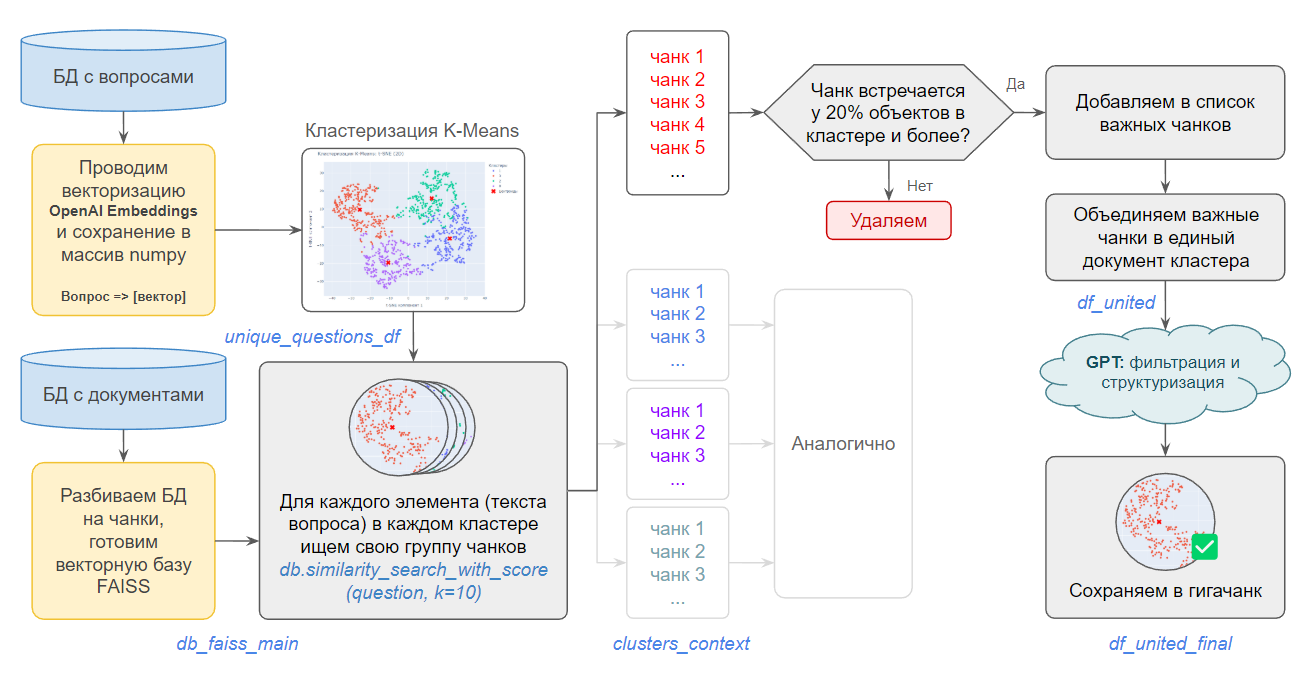

## **Примечание**

В документе предусмотрены блоки "**чекпоинт**". Они используются для загрузки результатов обработки данных, сохранённых на предыдущих этапах работы с ноутбуком. Это сделано для того, чтобы можно было продолжить с данного места, не производя все предыдущие вычисления повторно.

# **Теоретическая часть**

## Эмбеддинги и многомерное векторное пространство

Эмбеддинги — это способ представления текста (слов, фраз, предложений) в виде числовых векторов. Это позволяет компьютеру "понимать" текст, а не только работать с буквами и словами. Векторы представляют собой точки в многомерном пространстве, где каждая ось (измерение) соответствует определённому аспекту текста.

### Простое объяснение:
Представьте, что мы можем перевести текст в набор чисел, которые описывают его особенности. Например, фраза "Привет мир!" может быть преобразована в длинный список чисел. Эти числа — это и есть эмбеддинг.

### Пример с 3D-пространством:
Представьте, что мы оцениваем фразу по трём параметрам:
- Количество слов
- Количество символов
- Доля гласных букв

Тогда для фразы "Привет мир!" это будет выглядеть так:
- Количество слов = 2
- Количество символов = 10
- Доля гласных = 0.4

Таким образом, фразу можно представить как точку в трёхмерном пространстве: [2, 10, 0.4].

### Многомерное пространство:
Эмбеддинги на самом деле работают в гораздо более сложных пространствах, с тысячами измерений (например, 3072, как у модели OpenAI Embeddings). В таких пространствах текстовые данные "разбиваются" на маленькие части, и каждая часть — это одно измерение, которое описывает определённую характеристику смысла текста.

Близость точек в этом пространстве означает, что тексты, которые похожи по смыслу, будут расположены рядом, а те, что различаются, — на большом расстоянии друг от друга. Это позволяет находить схожие или связанные по смыслу фразы и предложения.

---

Многомерные вектора (эмбеддинги) проще всего представить на следующем примере.

Пример модели эмбеддинга для фразы-чанка **"Привет мир!"**:

```python
basic_embedding = {
    "word_count": 2,        # Количество слов
    "char_count": 10,       # Количество символов
    "unique_chars": 8,      # Уникальные символы
    "avg_word_length": 5.0, # Средняя длина слова
    "uppercase_ratio": 0.2, # Доля заглавных букв
    "vowel_ratio": 0.4      # Доля гласных
    # --- другие метрики текста ---
}
```
\* В примерах, названия параметров указаны для наглядности. **Реальный эмбеддинг это набор значений без их названий.**

Пример: `embedding = [0.0403, 0.2432, 0.0988, .... , 0.462]`

### Объяснение:
1. Каждый параметр — это **измерение** (ось).
2. Значения — это **координаты точки** в многомерном пространстве.
3. **Пример в 3D**:
   - Если `X = word_count`, `Y = char_count`, `Z = vowel_ratio`, то "Привет мир!" = `[2, 10, 0.4]`.
4. Близость точек = схожесть текстов.

Эмбеддинги = точки в пространстве, их расстояние отражает смысловую близость.


Модели, такие как **OpenAI Embeddings**, представляют текст в гораздо большем пространстве:
- **OpenAI Embeddings (text-embedding-3-large):**
  - Размерность = **3072**.
  - Каждый вектор имеет 3072 чисел, где каждое число кодирует определённый аспект смысла текста.

---

## Кластеризация.

Кластеризация - это объединение схожих данных в группы (кластеры) на основе их признаков.

Давайте сделаем наглядный пример кластеризации с использованием простых данных:

---

### Простейший пример

#### Данные (чанки и их basic_embedding):

```python
data = {
    "Сколько стоит курс ChatGPT Professional?": {"word_count": 6, "metric_1": 2, "metric_2": 0.45},
    "Расскажите про ChatGPT Professional": {"word_count": 4, "metric_1": 2.5, "metric_2": 0.42},
    "Какая продолжительность курсов?": {"word_count": 3, "metric_1": 3.6, "metric_2": 0.5},
    "Из чего состоит курс?": {"word_count": 4, "metric_1": 4.2, "metric_2": 0.48},
    "Что входит в программу курса?": {"word_count": 5, "metric_1": 4.11, "metric_2": 0.46},
    "Подскажите расписание занятий.": {"word_count": 3, "metric_1": 1.8, "metric_2": 0.33}
}
```

---

### **Визуализация на графике**

**Оси графика**:
   - X: `Признак 1` (metric_1).
   - Y: `Признак 2` (metric_2).

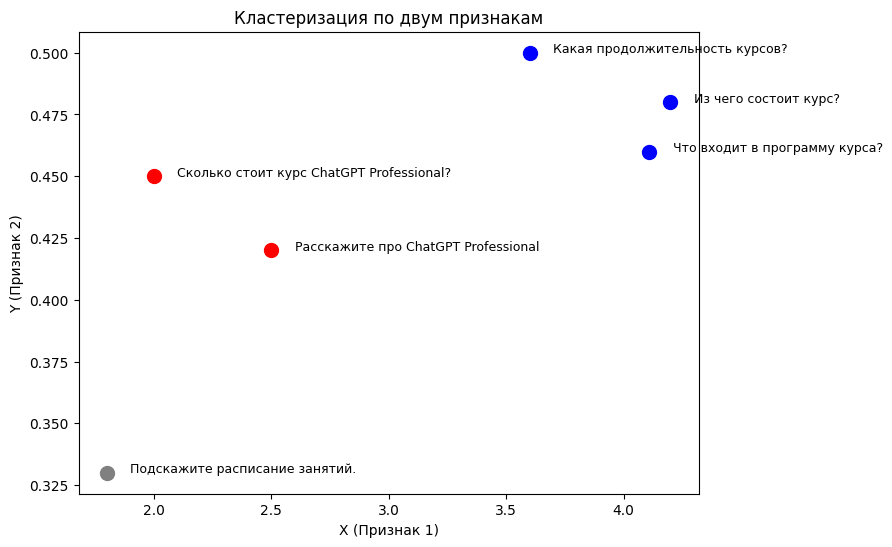

In [ ]:
# @title Python код для визуализации

import matplotlib.pyplot as plt

# Пример данных: точки на 2D-плоскости с явными кластерами
points = {
    "Сколько стоит курс ChatGPT Professional?": (2, 0.45),
    "Расскажите про ChatGPT Professional": (2.5, 0.42),
    "Какая продолжительность курсов?": (3.6, 0.5),
    "Из чего состоит курс?": (4.2, 0.48),
    "Что входит в программу курса?": (4.11, 0.46),
    "Подскажите расписание занятий.": (1.8, 0.33)
}

# Предопределённые кластеры вручную (0, 1, -1 для шума)
clusters = {
    "Сколько стоит курс ChatGPT Professional?": 0,
    "Расскажите про ChatGPT Professional": 0,
    "Какая продолжительность курсов?": 1,
    "Из чего состоит курс?": 1,
    "Что входит в программу курса?": 1,
    "Подскажите расписание занятий.": -1  # Шум
}

# Цвета для кластеров
colors = {0: 'red', 1: 'blue', -1: 'gray'}

# Построение графика
plt.figure(figsize=(8, 6))
for text, (x, y) in points.items():
    cluster = clusters[text]
    color = colors[cluster]
    plt.scatter(x, y, color=color, s=100, label=f"{text} (Cluster {cluster})" if cluster != -1 else f"{text} (Noise)")
    plt.text(x + 0.1, y, text, fontsize=9)

# Оформление графика
plt.xlabel("X (Признак 1)")
plt.ylabel("Y (Признак 2)")
plt.title("Кластеризация по двум признакам")
plt.show()

### Результат:

1. **Красные точки** — вопросы о ChatGPT Professional (Кластер 0).
2. **Синие точки** — вопросы о курсах (Кластер 1).
3. **Серые точки** — фразы, которые не попадают ни в один кластер (шум).



## Методы автоматической кластеризации **K-Means** и **DBSCAN**

Методы кластеризации нужны, чтобы автоматически находить похожие объекты и объединять их в группы. Это помогает:

* Делить клиентов на группы, чтобы понять, чем они отличаются.
* Искать похожие товары или тексты.
* Убирать лишние данные, которые не подходят ни к одной группе.

**K-Means**

* Делит данные на k групп (k задаем сами).
* Каждая группа формируется вокруг центроида (центра кластера).
* Кластеры получаются компактными и "круглыми".

**DBSCAN**

* Находит плотные участки данных и объединяет их в группы.
* Группы могут быть любой формы, даже "кривыми".
* Точки, которые не подходят ни к одной группе, считаются шумом.

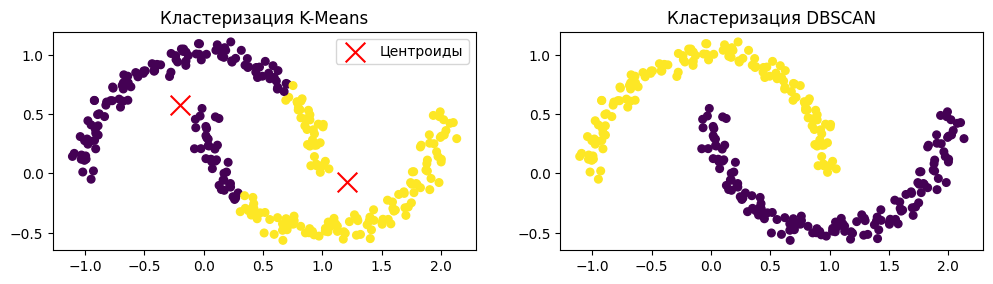

In [ ]:
# @title Пример на двумерном тестовом наборе данных Make Moons (два полумесяца)

# Импортируем необходимые библиотеки
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.datasets import make_moons

# Генерация искусственного набора данных Make Moons
# n_samples=300: генерируем 300 точек
# noise=0.05: добавляем немного шума (для более реалистичных данных)
# random_state=42: фиксируем генерацию случайных данных, чтобы результаты были одинаковыми при каждом запуске
X, _ = make_moons(n_samples=300, noise=0.05, random_state=42)

# Применяем алгоритм K-Means для кластеризации
# n_clusters=2: указываем, что данных два кластера (в соответствии с природой данных Make Moons)
# random_state=42: фиксируем случайное начальное состояние для воспроизводимости
kmeans = KMeans(n_clusters=2, random_state=42).fit(X)
# Получаем метки кластеров для каждой точки
kmeans_labels = kmeans.labels_
# Получаем координаты центроидов кластеров (центры кластеров)
kmeans_centroids = kmeans.cluster_centers_

# Применяем алгоритм DBSCAN для кластеризации
# eps=0.2: максимальное расстояние между точками, которые считаются соседями (чем меньше, тем более плотные кластеры)
# min_samples=5: минимальное количество точек, чтобы образовать кластер
dbscan = DBSCAN(eps=0.2, min_samples=5).fit(X)
# Получаем метки кластеров для каждой точки
dbscan_labels = dbscan.labels_

# Визуализация результатов кластеризации
# Создаем график с двумя подграфиками: один для K-Means, второй для DBSCAN
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Визуализируем результат K-Means кластеризации
# axes[0]: ссылаемся на первый подграфик (K-Means)
axes[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=30)  # Отображаем точки с цветами в зависимости от метки кластера
axes[0].scatter(
    kmeans_centroids[:, 0], kmeans_centroids[:, 1],  # Координаты центроидов кластеров
    s=200, c='red', marker='x', label='Центроиды'  # Рисуем центроиды красным крестиком
)
axes[0].set_title("Кластеризация K-Means")  # Заголовок для первого графика
axes[0].legend()  # Добавляем легенду
axes[0].set_aspect('equal')  # Устанавливаем одинаковый масштаб по осям для корректного отображения кластеров

# Визуализируем результат DBSCAN кластеризации
# axes[1]: ссылаемся на второй подграфик (DBSCAN)
axes[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=30)  # Отображаем точки с цветами в зависимости от метки кластера
axes[1].set_title("Кластеризация DBSCAN")  # Заголовок для второго графика
axes[1].set_aspect('equal')  # Устанавливаем одинаковый масштаб по осям для корректного отображения кластеров

# Показываем все графики
plt.show()

Данные алгоритмы работают вне зависимости от количества измерений.

**K-Means** работает хорошо, если группы:
* Имеют примерно одинаковый размер.
* Находятся на равном расстоянии друг от друга.
* Имеют чёткую границу и форму, похожую на круг или овал.

**DBSCAN** подходит, если группы:
* Имеют разную плотность.
* Могут быть вытянутыми, кривыми или любой другой формы.
* Есть "шумовые" точки, которые не подходят ни к одной группы.

Однако алгоритм DBSCAN более специфичен и применяется для сильно разнородных данных, где группы не пересекаются по смыслу. В рамках курса GPT Professional он вряд ли найдёт широкое применение, поэтому в данном занятии мы будем сосредотачиваться на работе с K-Means.

## Больше размерности!
### Если размерность эмбеддингов больше 2 (> 2D), то мы уже не сможем просто так отобразить их на плоскости. Поэтому для визуального отображения эмбеддингов применим методы снижения размерности. <br />Методы **PCA**, **t-SNE** и **UMAP**

*`Эти алгоритмы не изменяют сами данные, а используются только для их отображения в 2D или 3D.`*

Как мы помним, каждый эмбеддинг в OpenAI Embeddings (text-embedding-3-large) состоит из 3072 чисел (измерений), что делает невозможным его отображение на плоской диаграмме.

В реальных задачах количество измерений эмбеддингов может быть очень большим (как в случае OpenAI Embeddings). Методы снижения размерности, такие как PCA (анализ главных компонент), t-SNE (t-distributed stochastic neighbor embedding) и UMAP (uniform manifold approximation and projection), помогают представить данные из многомерного пространства в двумерном или трехмерном для их анализа и визуализации.

Например, PCA находит направления с максимальной вариативностью в данных и преобразует пространство так, чтобы сохранить как можно больше информации в проекциях. t-SNE и UMAP больше подходят для выявления кластеров и локальных структур в данных.

Важно помнить, что визуализация многомерных данных в 2D или 3D неизбежно приводит к упрощению визуальной информации. Такие методы помогают понять общую структуру данных, но не передают всю их многомерную природу.

Для простоты создадим эмбеддинги с числом измерений = 3. Их можно будет отобразить в привычном 3D пространстве.

In [ ]:
!pip install -q umap-learn==0.5.7

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.8/88.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 2.9 MB/s eta 0:00:00


In [ ]:
# @title Сгенерируем случайные эмбеддинги с размерностью = 3 (=3D) <br /> при помощи тестового набора данных Blobs <br /> и применим кластеризацию K-Means (k=4).

from sklearn.datasets import make_blobs  # Для генерации случайных данных
import plotly.express as px  # Для визуализации данных в 3D
from sklearn.cluster import KMeans  # Алгоритм кластеризации K-Means

# Генерация данных "шары"
# Создаем 1000 точек данных (n_samples=1000) с 4 центрами (centers=4)
# Каждая точка имеет 3 признака (n_features=3), стандартное отклонение внутри кластеров (cluster_std=5.0)
# random_state=42 используется для воспроизводимости результата
X, _ = make_blobs(n_samples=1000, centers=4, cluster_std=5.0, n_features=3, random_state=42)

# Применение K-Means
# Инициализируем модель K-Means для кластеризации данных на 4 кластера (n_clusters=4)
# random_state=42 обеспечивает воспроизводимость
kmeans = KMeans(n_clusters=4, random_state=42)

# Обучаем модель на данных X и получаем предсказанные метки кластеров для каждой точки
clusters = kmeans.fit_predict(X)

# Создание 3D-графика с Plotly
# Визуализация данных в 3D пространстве, где:
# x=X[:, 0] — значения первой координаты
# y=X[:, 1] — значения второй координаты
# z=X[:, 2] — значения третьей координаты
# color=clusters.astype(str) — цвет точек соответствует кластерам
fig_3d = px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    color=clusters.astype(str),  # Кластеры представлены как строки для удобной легенды
    title="Кластеризация K-Means: Данные Blobs (3D)"  # Заголовок графика
)

# Настраиваем размер маркеров (точек) на графике
fig_3d.update_traces(marker=dict(size=4))

# Устанавливаем размеры графика и параметры осей
fig_3d.update_layout(
    width=800,  # Ширина графика
    height=600,  # Высота графика
    scene=dict(  # Настройки для 3D пространства
        xaxis_title='X',  # Название оси X
        yaxis_title='Y',  # Название оси Y
        zaxis_title='Z'   # Название оси Z
    ),
    margin=dict(l=50, r=50, t=50, b=50),  # Отступы вокруг графика
    legend_title="Кластеры",  # Заголовок легенды
)

# Отображаем график
fig_3d.show()

In [ ]:
# @title Линейная проекция PCA

from sklearn.decomposition import PCA
import plotly.express as px

# Применение PCA для уменьшения размерности до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Преобразование центроидов K-Means в пространство PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)

# Создание 2D-графика с Plotly
fig_2d = px.scatter(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    color=clusters.astype(str),  # Цвет точек по меткам кластеров
    title="Кластеризация K-Means: PCA (2D)",
    labels={"x": "Главная компонента 1", "y": "Главная компонента 2", "color": "Кластер"}
)

# Добавление центроидов с всплывающей подсказкой
fig_2d.add_scatter(
    x=centroids_pca[:, 0],
    y=centroids_pca[:, 1],
    mode='markers',
    marker=dict(size=15, color='red', symbol='x'),  # Увеличенный размер центроидов
    name='Центроиды',
    hoverinfo='text',  # Включаем только всплывающую подсказку
    text=[f'Центроид кластера {i}<br>Координаты: ({centroid[0]:.2f}, {centroid[1]:.2f})'
          for i, centroid in enumerate(centroids_pca)]
)

# Настройки для кластерных точек
fig_2d.data[0].update(marker=dict(size=6))  # Применяем размер только к точкам кластеров

# Настройки графика
fig_2d.update_layout(
    width=800,
    height=600,
    xaxis_title="Главная компонента 1",
    yaxis_title="Главная компонента 2",
    legend_title="Кластеры",
    margin=dict(l=50, r=50, t=50, b=50)  # Отступы
)
fig_2d.show()

In [ ]:
# @title Нелинейная проекция t-SNE

from sklearn.manifold import TSNE
import plotly.express as px
import numpy as np

# Применение t-SNE для уменьшения размерности до 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X)

# Рассчёт "центроидов" в пространстве t-SNE как средних координат кластеров
centroids_tsne = np.array([
    X_tsne[clusters == cluster].mean(axis=0)
    for cluster in range(kmeans.n_clusters)
])

# Создание 2D-графика с Plotly
fig_tsne = px.scatter(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    color=clusters.astype(str),  # Цвет точек по меткам кластеров
    title="Кластеризация K-Means: t-SNE (2D)",
    labels={"x": "t-SNE компонент 1", "y": "t-SNE компонент 2", "color": "Кластер"}
)

# Добавление центроидов с всплывающими подсказками
fig_tsne.add_scatter(
    x=centroids_tsne[:, 0],
    y=centroids_tsne[:, 1],
    mode='markers',
    marker=dict(size=15, color='red', symbol='x'),  # Увеличенный размер центроидов
    name='Центроиды',
    hoverinfo='text',  # Включаем только всплывающую подсказку
    text=[f'Центроид кластера {i}<br>Координаты: ({centroid[0]:.2f}, {centroid[1]:.2f})'
          for i, centroid in enumerate(centroids_tsne)]
)

# Настройки для кластерных точек
fig_tsne.data[0].update(marker=dict(size=6))  # Применяем размер только к точкам кластеров

# Настройки графика
fig_tsne.update_layout(
    width=800,
    height=600,
    xaxis_title="t-SNE компонент 1",
    yaxis_title="t-SNE компонент 2",
    legend_title="Кластеры",
    margin=dict(l=50, r=50, t=50, b=50)  # Отступы
)
fig_tsne.show()

In [ ]:
# @title Нелинейная проекция UMAP

import umap
import plotly.express as px
import numpy as np

# Применение UMAP для уменьшения размерности до 2D
umap_reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, n_jobs=-1) #, random_state=42)
X_umap = umap_reducer.fit_transform(X)

# Рассчёт "центроидов" в пространстве UMAP как средних координат кластеров
centroids_umap = np.array([
    X_umap[clusters == cluster].mean(axis=0)
    for cluster in range(kmeans.n_clusters)
])

# Создание 2D-графика с Plotly
fig_umap = px.scatter(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    color=clusters.astype(str),  # Цвет точек по меткам кластеров
    title="Кластеризация K-Means: UMAP (2D)",
    labels={"x": "UMAP компонент 1", "y": "UMAP компонент 2", "color": "Кластер"}
)

# Добавление центроидов с всплывающими подсказками
fig_umap.add_scatter(
    x=centroids_umap[:, 0],
    y=centroids_umap[:, 1],
    mode='markers',
    marker=dict(size=15, color='red', symbol='x'),  # Увеличенный размер центроидов
    name='Центроиды',
    hoverinfo='text',  # Включаем только всплывающую подсказку
    text=[f'Центроид кластера {i}<br>Координаты: ({centroid[0]:.2f}, {centroid[1]:.2f})'
          for i, centroid in enumerate(centroids_umap)]
)

# Настройки для кластерных точек
fig_umap.data[0].update(marker=dict(size=6))  # Применяем размер только к точкам кластеров

# Настройки графика
fig_umap.update_layout(
    width=800,
    height=600,
    xaxis_title="UMAP компонент 1",
    yaxis_title="UMAP компонент 2",
    legend_title="Кластеры",
    margin=dict(l=50, r=50, t=50, b=50)  # Отступы
)
fig_umap.show()

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



**PCA (Principal Component Analysis)**:

Это линейная проекция, которая ищет новые оси (главные компоненты), сохраняющие максимальную вариативность данных. Проекция выполняется в пространстве с меньшим числом измерений без потери основной информации.

**t-SNE (t-distributed Stochastic Neighbor Embedding)**:

Это нелинейная проекция, которая сохраняет локальные структуры данных (соседства) при переходе в пространство с меньшим числом измерений. Она используется для визуализации сложных кластеров.

**UMAP (Uniform Manifold Approximation and Projection)**:
Это также нелинейная проекция, которая сохраняет глобальные и локальные структуры данных, но делает это быстрее и точнее по сравнению с t-SNE.

**Чем отличаются?**
* PCA часто называют "аналитической проекцией", так как она опирается на линейную алгебру и сохраняет глобальную структуру.
* t-SNE и UMAP — более "интуитивные" методы, которые лучше подходят для визуализации, но могут искажать глобальные расстояния.

---

**Итог**:
- Кластеризация группирует объекты (фразы) на основе их признаков.
- Визуализация показывает, как точки (фразы) распределены в пространстве.
- Близость точек отражает их схожесть, а кластеры упрощают анализ.

---
---
---

# **Перейдем к реальным данным.**

### **Выполнить перед началом работы**. Подготовка. Установка библиотек, подключение к OpenAI...

In [ ]:
# @title Установка библиотек
!pip install -q langchain langchain-community langchain-core langchain-openai langchain-text-splitters langsmith openai faiss-cpu

In [ ]:
# @title Импорты

import os
import copy
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from tqdm import tqdm_notebook as tqdm
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from google.colab import userdata
from langchain.text_splitter import (
    CharacterTextSplitter,
    NLTKTextSplitter,
    RecursiveCharacterTextSplitter,
)
from langchain.docstore.document import Document
from langchain.document_loaders import TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
import openai
from openai import AsyncOpenAI, OpenAI
import tiktoken

warnings.filterwarnings("ignore")

In [ ]:
# @title Функция для загрузки данных из Яндекс.Диска в рабочий каталог **root_path**

import os
import requests
import zipfile
import shutil

def download_and_extract_yandex_disk(url, output_dir):
    """
    Скачивает архив с Яндекс.Диска и распаковывает содержимое корневой папки в указанный каталог.

    :param url: Ссылка на файл или папку на Яндекс.Диске (публичная).
    :param output_dir: Папка, куда будет распаковано содержимое архива.
    """
    os.makedirs(output_dir, exist_ok=True)
    zip_file_path = os.path.join(output_dir, 'data.zip')

    # Преобразование ссылки для прямого скачивания
    direct_url = f"https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key={url}"
    response = requests.get(direct_url)
    if response.status_code != 200:
        print(f"Ошибка при запросе ссылки: {response.status_code}")
        return False

    download_link = response.json().get('href')
    if not download_link:
        print("Не удалось получить ссылку для скачивания.")
        return False

    # Скачиваем файл
    with requests.get(download_link, stream=True) as file_response:
        with open(zip_file_path, 'wb') as file:
            shutil.copyfileobj(file_response.raw, file)
    print(f"Файл успешно загружен: {zip_file_path}")

    # Распаковываем содержимое архива
    if zipfile.is_zipfile(zip_file_path):
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            for member in zip_ref.namelist():
                # Извлекаем только файлы без корневой папки
                member_path = os.path.relpath(member, start=os.path.commonpath(zip_ref.namelist()))
                target_path = os.path.join(output_dir, member_path)
                if not member.endswith('/'):  # Пропускаем директории
                    os.makedirs(os.path.dirname(target_path), exist_ok=True)
                    with open(target_path, 'wb') as f:
                        f.write(zip_ref.read(member))
        print(f"Файлы успешно распакованы в папку: {output_dir}")
        os.remove(zip_file_path)  # Удаляем архив после распаковки
        return True
    else:
        print("Скачанный файл не является ZIP-архивом.")
        return False

In [ ]:
# @title Служебные функции и переменные ноутбука

# Подсчет токенов в строке
def num_tokens_from_string(string: str, encoding_name: str) -> int:
    encoding = tiktoken.get_encoding(encoding_name)
    return len(encoding.encode(string))

# Функция для расчета стоимости запросов
def calculate_cost(complition_questions, usd_price, verbose=False):
    """
    Функция для расчета стоимости входных и выходных токенов, а также общей стоимости запроса.

    :param complition_questions: Объект с информацией о токенах (предполагается, что он имеет атрибуты usage.prompt_tokens и usage.completion_tokens)
    :param usd_price: Цена одного доллара в рублях
    :return: Словарь с рассчитанной стоимостью
    """
    # print('complition_questions ', complition_questions)

    input_price = pricing_per_million_tokens_usd.get(complition_questions.model)["input_price"]
    output_price = pricing_per_million_tokens_usd.get(complition_questions.model)["output_price"]

    prompt_tokens_cost = ((int(complition_questions.usage.prompt_tokens) * input_price) / 1000000) * usd_price
    completion_tokens_cost = ((int(complition_questions.usage.completion_tokens) * output_price) / 1000000) * usd_price
    total_cost = prompt_tokens_cost + completion_tokens_cost

    cost_details = {
        "prompt_tokens_cost": prompt_tokens_cost,
        "completion_tokens_cost": completion_tokens_cost,
        "total_cost": total_cost
    }
    if verbose:
        print(f"Цена {complition_questions.usage.prompt_tokens} входных токенов, руб: {prompt_tokens_cost}")
        print(f"\nЦена {complition_questions.usage.completion_tokens} выходных токенов, руб: {completion_tokens_cost}")
        print(f"\nЦена запроса, руб: {total_cost}")

    return cost_details

def calculate_total_cost(data):
    # Инициализируем переменную для общей стоимости
    total_cost = 0

    # Проходим по каждому элементу списка и извлекаем значение 'total_cost'
    for item in data:
        for key, value in item.items():
            total_cost += value['total_cost']

    # Печатаем общую стоимость
    return f"Общая стоимость вызовов для запроса: {total_cost:.5f} руб"


# Корневая папка занятия
root_path = '/content/drive/MyDrive/Занятия УИИ/Исследование БД. Кластеризация/'

# Пути и другие переменные ноутбука
db_index_path = "/faiss_index/"
text_file = 'base_uii_edit_22.txt'

# Модель GPT
model_answer = 'gpt-4o-mini'

len_chunk = 1024


# Производим загрузку данных для чекпоинтов с Яндекс.Диска
files_url = "https://disk.yandex.ru/d/94pepH9co6ZijQ"
local_path = '/content/local_data'

if download_and_extract_yandex_disk(files_url, local_path):
    # Переназначаем корневую папку занятия на папку загрузки с Яндекс.Диска
    root_path = local_path + '/'
    print(f'Корневая папка занятия изменена на: {root_path}')

Файл успешно загружен: /content/local_data/data.zip
Файлы успешно распакованы в папку: /content/local_data
Корневая папка занятия изменена на: /content/local_data/


In [ ]:
# @title Установка цен для расчета стоимости запросов
usd_price = 110
encoding_name = "cl100k_base"
model_parsed = 'gpt-4o-mini-2024-07-18'
# Define pricing embed for each model in USD per 1M tokens
pricing_per_million_tokens_usd = {
    "gpt-4o-mini": {"input_price": 0.15, "output_price": 0.6},
    "gpt-4o-mini-2024-07-18": {"input_price": 0.15, "output_price": 0.6},
    "gpt-4o": {"input_price": 2.5, "output_price": 10},
    "gpt-4o-2024-08-06": {"input_price": 2.5, "output_price": 10},
    "gpt-4o-2024-05-13": {"input_price": 10, "output_price": 15},
    "text-embedding-3-small": 0.020,
    "text-embedding-3-large": 0.130,
    "text-embedding-ada-002": 0.100
    }

history_cost = []

In [ ]:
# @title Загружаем ключ OpenAI

openai.api_key = userdata.get("OPENAI_API_KEY")
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

model_embed_large = "text-embedding-3-large"
embeddings_large = OpenAIEmbeddings(model=model_embed_large)

model_embed = "text-embedding-ada-002"  # ["text-embedding-3-small", "text-embedding-3-large", "text-embedding-ada-002"]
embeddings = OpenAIEmbeddings(model=model_embed)

### Загрузка данных и получение их векторного представления (эмбеддингов)

In [ ]:
# @title Загрузка документа с вопросами

def load_unique_questions(file_path):
    # Чтение файла xlsx
    df = pd.read_excel(file_path)

    # Извлечение списка вопросов
    unique_questions = df['Вопрос'].tolist()

    return unique_questions

file_path = root_path + 'filtered_unique_questions.xlsx'  # xlsx документ с вопросами
unique_questions = load_unique_questions(file_path)

In [ ]:
# @title Получение векторного представления вопросов (эмбеддингов) <br />**OpenAIEmbeddings(model="text-embedding-3-large")**
# Получаем векторные представления вопросов
vectors = embeddings_large.embed_documents(unique_questions)

# Преобразуем векторы в numpy массив
vectors = np.array(vectors)

In [ ]:
# @title Вывод 5 первых строк из БД и их векторного представления

print('----------------------------------------------------------------')
print(f'\033[1;034mПервые 5 вопросов из базы\033[0m (\033[1;091m{len(unique_questions)}\033[0m строк)')
display(unique_questions[:5])
print(f'\n\033[1;034mИх векторное представление\033[0m (\033[1;091m{len(vectors)}\033[0m векторов)')
display(vectors[:5])
print('----------------------------------------------------------------')

----------------------------------------------------------------
Первые 5 вопросов из базы (3056 строк)


['Построй план обучения студента по курсу chatGPT professional',
 'что будет изучаться на программе нейронных сетей на тему маркетинга?',
 'Что входит в тариф ПРдвинутый?',
 'как проходят стажировки?',
 'РАсскажи про продвинутый тариф chatGPT']


Их векторное представление (3056 векторов)


array([[-0.00882505, -0.02244241,  0.00324381, ..., -0.00259779,
         0.00178733,  0.01253674],
       [-0.0326079 , -0.02853493, -0.00545875, ..., -0.00860386,
         0.00342829, -0.00176234],
       [-0.03962782,  0.0132984 , -0.01135641, ...,  0.00166142,
         0.00049429,  0.00479868],
       [-0.03350367, -0.01883504, -0.01037292, ..., -0.00933132,
        -0.00762166,  0.01206104],
       [-0.04153878, -0.02702866, -0.00065299, ..., -0.01424142,
         0.00758304,  0.02470514]])

----------------------------------------------------------------


**Внимание!** Результаты векторизации vectors могут отличаться про повторном запуске

In [ ]:
# @title Сохраняем вопросы и результат векторизации (**unique_questions** и **vectors**)

# # Сохранение векторов в файл
# with open(root_path + 'vectors.npy', 'wb') as f:
#     np.save(f, vectors)
#     print('Векторы успешно сохранены в vectors.npy')#

# unique_questions_json = json.dumps(unique_questions, ensure_ascii=False)
# with open(root_path + 'unique_questions.json', 'w', encoding='utf-8') as f:
#     f.write(unique_questions_json)
#     print('Список вопросов успешно сохранён в unique_questions.json')

In [ ]:
# @title Чекпоинт (загрузка **unique_questions** и **vectors**) <br />[Следующий чекпоинт](#scrollTo=2woh3rIxXaiR)

with open(root_path + 'vectors.npy', 'rb') as f:
    vectors = np.load(f)
    print('Векторы успешно загружены из vectors.npy')
with open(root_path + 'unique_questions.json', 'r', encoding='utf-8') as f:
    unique_questions = json.load(f)
    print('Список вопросов успешно загружен из unique_questions.json')

Векторы успешно загружены из vectors.npy
Список вопросов успешно загружен из unique_questions.json


---
---
---

## Попробуем найти крупные кластеры методом **DBSCAN** (для сравнения методов кластеризации)

In [ ]:
# @title Кластеризация методом **DBSCAN**
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics.pairwise import cosine_distances

# Параметры кластеризации
eps = 0.28  # Радиус окрестности
min_samples = 25  # Минимальное количество точек для формирования кластера
metric = 'precomputed'  # Метрика расстояния

# Вычисление косинусной матрицы расстояний
distance_matrix = cosine_distances(vectors)

# Выполнение кластеризации DBSCAN
dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric=metric)
clusters_dbscan = dbscan.fit_predict(distance_matrix)

# Добавляем результаты кластеризации в DataFrame
cluster_df = pd.DataFrame(vectors, columns=[f'Dim{i}' for i in range(vectors.shape[1])])
cluster_df['Cluster'] = clusters_dbscan

In [ ]:
# @title Подготовка **t-SNE** для снижения размерности
from sklearn.manifold import TSNE

# Параметры для t-SNE
n_components = 2  # Снижение размерности до 2D
random_state = 42

# Применение t-SNE
tsne = TSNE(n_components=n_components, random_state=random_state, metric='precomputed', init='random')
tsne_results = tsne.fit_transform(distance_matrix)

# Создаём DataFrame с результатами t-SNE
tsne_df = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
tsne_df['Cluster'] = clusters_dbscan

In [ ]:
# @title Визуализация кластеризации методом **DBSCAN** / **t-SNE**
import plotly.express as px
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

# Добавляем столбец с вопросами в DataFrame для визуализации
tsne_df['Question'] = unique_questions

# Создаём scatter plot для кластеров
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='Cluster',
    hover_data={'TSNE1': False, 'TSNE2': False, 'Cluster': True, 'Question': True},
    title='DBSCAN Clustering (t-SNE Visualization with Annotations)',
    color_discrete_sequence=px.colors.qualitative.Bold + px.colors.qualitative.Pastel
)

# Добавляем контуры кластеров
for cluster_id in tsne_df['Cluster'].unique():
    if cluster_id == -1:  # Пропускаем шумовые точки
        continue
    cluster_points = tsne_df[tsne_df['Cluster'] == cluster_id][['TSNE1', 'TSNE2']].values
    if len(cluster_points) >= 3:  # ConvexHull требует минимум 3 точки
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]
        hull_points = np.append(hull_points, [hull_points[0]], axis=0)  # Замыкаем контур

        # Добавляем область кластера
        fig.add_trace(go.Scatter(
            x=hull_points[:, 0],
            y=hull_points[:, 1],
            mode='lines',
            line=dict(color='rgba(0,0,0,0.5)', width=1),
            fill='toself',
            fillcolor='rgba(0, 0, 0, 0.1)',
            name=f'Cluster {cluster_id} Area',
            visible='legendonly'  # По умолчанию скрыть области
        ))

# Настраиваем макет
fig.update_layout(
    height=800,
    coloraxis_colorbar=dict(title='Cluster', x=0.95),
    legend=dict(title='Clusters', itemsizing='constant')
)

fig.show()

#### **Что мы видим на диаграмме?**
  
На диаграмме видно, что некоторые кластеры не выделены полностью, поскольку отдельные точки отнесены к шуму. Кроме того, существуют кластеры, смысл которых "перетекает" из одного в другой. Это связано с тем, что эти кластеры формируют более крупные "облака" плотности и сливаются друг с другом.

**Вывод:**  
Данный метод плохо подходит для наших данных, так как он сильно зависит от настройки параметров:

- **Радиус окрестности (eps):**  
  Если радиус слишком мал, кластеры будут "разрываться", а многие точки окажутся шумом.  
  Если радиус слишком велик, кластеры могут слиться в один.

- **Минимальное количество точек (min_samples):**  
  Если это значение слишком велико, мелкие, но значимые кластеры не будут обнаружены.  
  Если значение слишком мало, даже случайные скопления точек будут восприниматься как кластеры.

Кроме того, DBSCAN плохо работает с данными, где плотность точек в кластерах сильно различается. Это приводит к тому, что одни кластеры объединяются, а другие распадаются на шум. Для данного набора данных лучше использовать методы, менее зависящие от плотности, например, **K-Means** или **иерархическую кластеризацию**.

## Кластеризация вопросов **K-Means** (1-я ветка алгоритма) ==> **unique_questions_df**

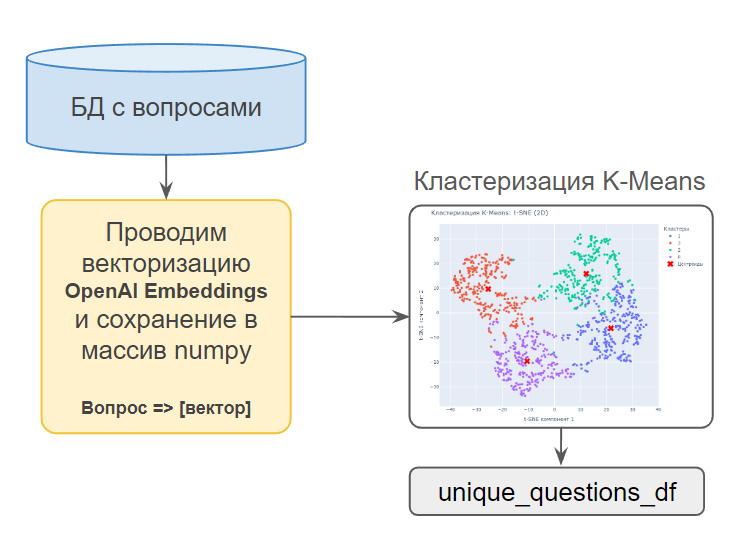

### **K-Means**

#### **Метод локтя для определения оптимального количества кластеров**

Метод локтя — это способ выбора оптимального количества кластеров (групп) при применении алгоритма **K-Means** для кластеризации данных.

**Суть метода локтя:**
* **Инерция** — это сумма квадратов расстояний от каждого объекта до ближайшего центра кластера. Чем меньше инерция, тем лучше кластеризация.
* Для определения оптимального числа кластеров мы запускаем алгоритм K-Means для разных значений числа кластеров.
* Для каждого числа кластеров мы вычисляем инерцию.
* На графике отображаем зависимость инерции от количества кластеров. Обычно инерция убывает по мере увеличения числа кластеров.
* Мы ищем на графике "**локоть**" — точку, после которой дальнейшее увеличение числа кластеров приводит к заметно меньшему уменьшению или даже увеличению инерции. Это и будет оптимальное количество кластеров, поскольку добавление еще одного кластера не дает значительного улучшения.

**Почему называется "метод локтя"?**
График инерции обычно выглядит как кривой, где на определенном этапе (в "локте") сокращение инерции замедляется. Это место и называют "локтем".

**Пример:**
1. Запускаем алгоритм K-Means для разных значений K (например, от 1 до 10).
2. Строим график инерции для каждого значения K.
3. Находим точку, где график начинает выравниваться (локоть). Это и будет оптимальное количество кластеров.

Метод локтя — это быстрый и удобный способ выбрать нужное количество кластеров, особенно когда нужно работать с большими данными и нельзя провести все вычисления вручную.

#### Метод локтя на логарифмической шкале

Данный метод позволяет без длительных вычислений охватить довольно большой диапазон количества кластеров. Это помогает понять, есть ли аномалии при кластеризации, а также визуально определить место начала снижения инерции из-за появления кластеров с нулевой инерцией (с единственным объектом).

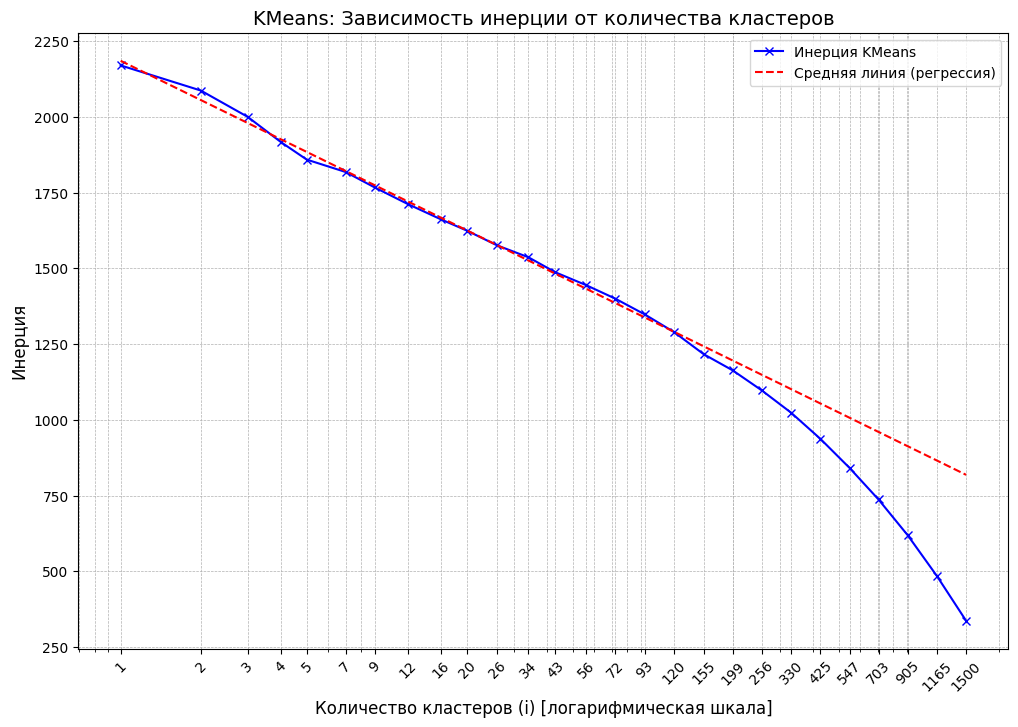

In [ ]:
# @title Код

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Данные для логарифмической прогрессии и инерции
i_values = np.logspace(np.log10(1), np.log10(1500), num=30, dtype=int)
i_values = np.unique(i_values)  # Удаление повторений
distortions = []

# Вычисление инерции для каждого количества кластеров
for i in i_values:
    if i <= len(vectors):  # Ограничиваем количество кластеров числом точек
        kmean = KMeans(n_clusters=i, random_state=42)
        kmean.fit(vectors)  # Используем ваши реальные данные
        distortions.append(kmean.inertia_)  # Сохраняем значение инерции (сумма внутрикластерных расстояний)

# Преобразование данных для регрессии
log_i_values = np.log10(i_values).reshape(-1, 1)  # Логарифм X для линейной регрессии
distortions = np.array(distortions)

# Разделяем данные на первые 2/3 и последние 1/3
split_point = int(len(i_values) * 2 / 3)

# Линейная регрессия только для первых двух третей
reg_model = LinearRegression()
reg_model.fit(log_i_values[:split_point], distortions[:split_point])

# Предсказания для всей линии
reg_line = reg_model.predict(log_i_values)

# Построение графика
plt.figure(figsize=(12, 8))

# Основная линия зависимости
plt.plot(i_values, distortions, 'bx-', label="Инерция KMeans")

# Средняя прямая (регрессия)
plt.plot(i_values, reg_line, 'r--', label="Средняя линия (регрессия)")

plt.xscale('log')  # Логарифмическая шкала для оси X
plt.xlabel("Количество кластеров (i) [логарифмическая шкала]", fontsize=12)
plt.ylabel("Инерция", fontsize=12)
plt.title("KMeans: Зависимость инерции от количества кластеров", fontsize=14)
plt.xticks(i_values, labels=i_values, rotation=45)
plt.legend()
plt.grid(which='both', linestyle='--', linewidth=0.5)
plt.show()

Рассмотрим диаграмму подробнее.

1. **Область нестабильности.** Видим более выраженные изменения на начальных этапах, когда количество кластеров невелико.
2. **Небольшие отклонения** наблюдаются на основной линии тренда. Явных аномалий не выявлено.
3. **Расхождение со средней линией.** Когда количество кластеров становится слишком большим, каждый новый кластер начинает включать в себя только одну точку (или несколько очень близких точек), что не имеет практической ценности для модели. Это "переобучение" приводит к сильному снижению инерции, но с точки зрения полезности кластеров такая ситуация уже не имеет смысла, поскольку каждый кластер содержит лишь одну точку и не выполняет свою роль в разделении данных.

Появление подобного расхождения со средней линией может говорить о недостаточности объема исходных данных для кластеризации с большим (>150) количеством кластеров. В нашем случае, это ~5% от объема датасета.

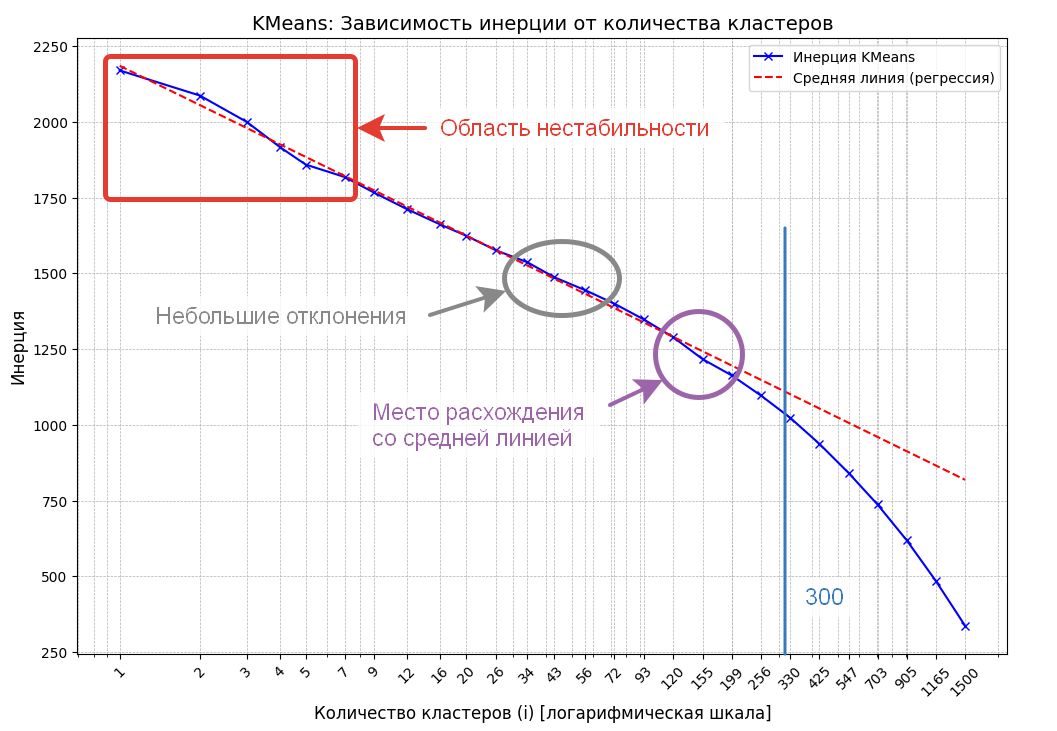

Давайте разберемся по шагам:

##### 1. **Переобучение (overfitting)**

Термин "переобучение" в контексте кластеризации, хотя и заимствован из машинного обучения, обозначает следующее: когда количество кластеров становится слишком большим, алгоритм начинает "разделять" данные на очень маленькие и точные группы. Иными словами, количество кластеров настолько велико, что каждый кластер может содержать всего одну точку или несколько очень похожих точек, которые практически не имеют различий между собой.

**Почему это считается переобучением?**
 * Алгоритм в данном случае не решает задачу полезной кластеризации, а просто «запоминает» каждый объект как отдельную группу, что приводит к уменьшению инерции (потому что объекты расположены ближе друг к другу и более точно попадают в соответствующие кластеры). Это может дать очень хорошую метрику качества модели, но она не будет иметь практической ценности.
 * Например, если вы разбиваете данные на 1000 кластеров для 1000 объектов, каждый кластер будет содержать только один объект. В этом случае кластеризация не помогает понять структуру данных, потому что каждый объект остается "сам по себе".

##### 2. **Почему это не имеет смысла с точки зрения полезности?**

Кластеры должны объединять объекты, которые имеют схожие характеристики. Когда количество кластеров слишком велико, каждый кластер становится практически индивидуальным для каждого объекта. Это лишает кластеризацию ее полезности, так как она больше не помогает выявить общие закономерности или скрытые группы в данных. В таком случае, кластеризация превращается в бессмысленную разбиение данных на микро-группы, что не решает задач анализа.

##### 3. **Почему каждый кластер содержит одну точку?**
Если количество кластеров слишком большое, то для большинства точек данных алгоритм выделяет отдельный кластер. То есть, для \( N \) объектов и \( N \) кластеров, каждый объект будет в своем собственном кластере. В результате каждый кластер будет включать только одну точку.

##### 4. **Средняя линия (регрессия)**
Когда вы строите график зависимости инерции от количества кластеров, вы можете провести линию тренда, которая будет показывать, как инерция изменяется по мере увеличения числа кластеров. Средняя линия (или линия тренда) — это просто линия, которая отражает общий тренд, а не каждое отдельное изменение. В нормальных условиях инерция будет снижаться, но после определенного момента (в районе локтя) снижение будет замедляться. Если число кластеров становится слишком большим, вы увидите, что инерция продолжает снижаться, но это уже не имеет практического смысла — кластеры становятся слишком мелкими.

##### **Итого:**
Когда количество кластеров становится слишком большим, алгоритм "перегибает палку" — кластеры становятся слишком маленькими, и каждая точка оказывается в своем собственном кластере, что не имеет смысла для анализа. Снижение инерции в этом случае не помогает, а наоборот, приводит к искажению результатов.

---

### Для наглядности, построим линейную диаграмму по первым 300 точек.

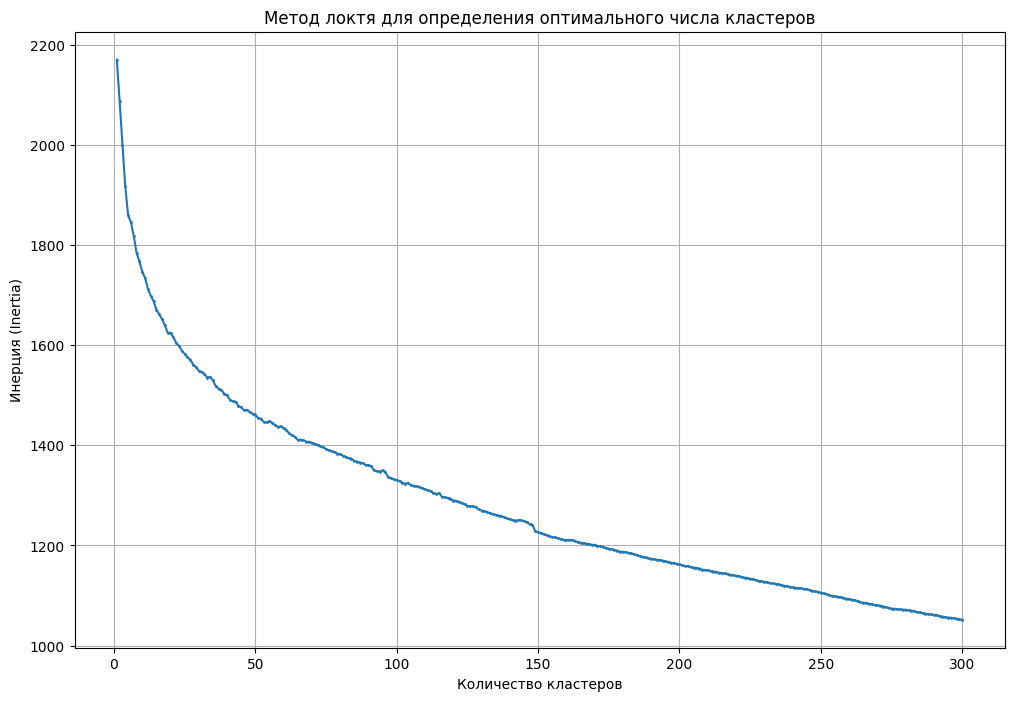

In [ ]:
# @title ########### НЕ ЗАПУСКАТЬ! ВРЕМЯ ВЫПОЛНЕНИЯ БОЛЕЕ 30 МИНУТ!!! ###########

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Функция для исследования методом локтя
def elbow_method(vectors, max_clusters=300):
    distortions = []
    cluster_range = range(1, max_clusters + 1)

    # Вычисление искажения (distortion) для каждого количества кластеров
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(vectors)
        distortions.append(kmeans.inertia_)  # Сохраняем значение суммы внутрикластерных расстояний

    # Построение графика
    plt.figure(figsize=(12, 8))  # Увеличиваем размер диаграммы
    plt.plot(cluster_range, distortions, marker='o', markersize=1)  # Уменьшаем размер точки
    plt.title('Метод локтя для определения оптимального числа кластеров')
    plt.xlabel('Количество кластеров')
    plt.ylabel('Инерция (Inertia)')
    plt.grid()
    plt.show()

elbow_method(vectors)

Видим, что есть небольшие колебания близкие к точке расходнеия. От 130 до 150.

Выделим эту область более подробно.

In [ ]:
# @title Расчет данных для области области 130-150 кластеров<br />(место расхождения со средней линией и замеченная аномалия в этой области)

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np

# Функция для исследования методом локтя
def elbow_method(vectors, cluster_range):
    distortions = []
    # Вычисление инерции для каждого количества кластеров
    for k in cluster_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(vectors)
        distortions.append(kmeans.inertia_)  # Сохраняем значение суммы внутрикластерных расстояний
    return distortions

# Задаем диапазон кластеров
min_clusters=130
max_clusters=150
cluster_range = range(min_clusters, max_clusters + 1)

# Получаем набор данных для метода локтя
distortions = elbow_method(vectors, cluster_range)

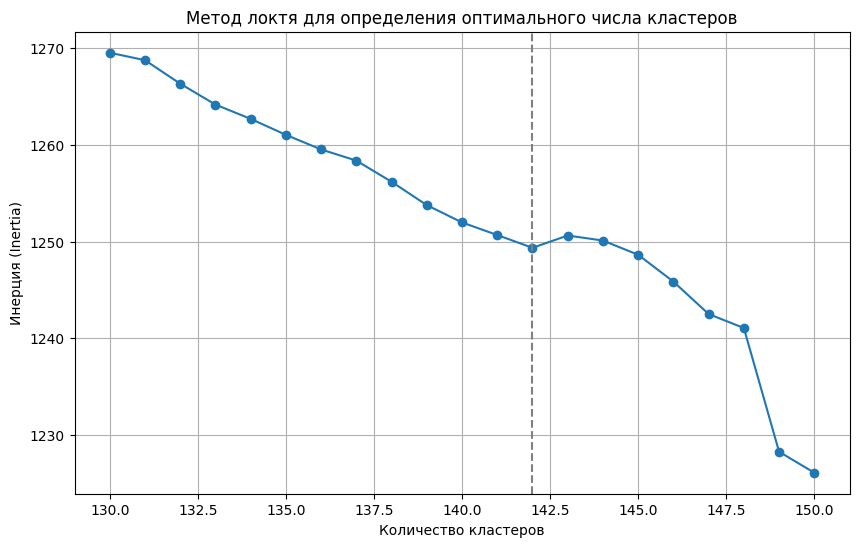

In [ ]:
# @title Построение графика области
plt.figure(figsize=(10, 6))
plt.plot(cluster_range, distortions, marker='o')

# Добавляем вертикальную пунктирную линию на отметке 142
plt.axvline(x=142, color='gray', linestyle='--')

plt.title('Метод локтя для определения оптимального числа кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Инерция (Inertia)')  # Изменено на "Инерция"
plt.grid()
plt.show()

Локальный минимум. Из данной диаграммы видно, что наилучшей точкой можно считать 142 кластера.

#### Кластеризация K-Means

In [ ]:
# @title Готовим автоматическую кластеризацию эмбеддингов **OpenAIEmbeddings** при помощи **K-means** <br />**Количество кластеров = 142**

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import plotly.express as px
import numpy as np

# Применение K-means кластеризации
n_clusters = 142  # Количество кластеров
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(vectors)  # Используем векторные представления

# Получаем центроиды кластеров
centroids = kmeans.cluster_centers_

# Сохраняем центроиды в .npy
np.save(root_path + 'centroids.npy', centroids)
print("Центроиды успешно сохранены в файл centroids.npy")

# Вариант 1: Таблица с колонками "Вопрос" и "Кластер"
df_clusters = pd.DataFrame({
    'Вопрос': unique_questions,
    'Кластер': clusters
})

# Сохранение таблицы в файл CSV
df_clusters.to_csv(root_path + 'clusters.csv', index=False, encoding="utf-8")  # Сохранение без индекса
print("Кластеры успешно сохранены в файл clusters.csv")

Центроиды успешно сохранены в файл centroids.npy
Кластеры успешно сохранены в файл clusters.csv


In [ ]:
# @title Готовим **t-SNE**

# Применение t-SNE к эмбеддингам
tsne = TSNE(n_components=2, random_state=42, learning_rate='auto', init='random')
tsne_results = tsne.fit_transform(vectors)  # Входные данные - векторы

# Создание DataFrame для результатов t-SNE
tsne_df = pd.DataFrame({
    'TSNE1': tsne_results[:, 0],
    'TSNE2': tsne_results[:, 1],
    'Cluster': clusters,  # Используем номера кластеров
    'Message': unique_questions  # Связываем сообщения с результатами t-SNE
})

# Вычисление средних значений (приблизительных координат) для центроидов на плоскости
centroids_df = tsne_df.groupby('Cluster')[['TSNE1', 'TSNE2']].mean().reset_index()

# Форматируем текст для отображения при наведении на центроиды
centroids_df['text'] = centroids_df.apply(
    lambda row: f"Номер кластера: {row['Cluster']}\nКоординаты: ({row['TSNE1']:.2f}, {row['TSNE2']:.2f})",
    axis=1
)

In [ ]:
# @title Визуализация результатов **OpenAIEmbeddings / K-means / t-SNE**
import plotly.graph_objects as go
from scipy.spatial import ConvexHull

# Создаём scatter plot для точек кластеров
fig = px.scatter(
    tsne_df,
    x='TSNE1',
    y='TSNE2',
    color='Cluster',
    hover_data={'Cluster': True, 'TSNE1': False, 'TSNE2': False, 'Message': True},
    title='t-SNE визуализация кластеризации сообщений'
)

# Добавляем скрытые контуры для каждого кластера
for cluster_id in tsne_df['Cluster'].unique():
    cluster_points = tsne_df[tsne_df['Cluster'] == cluster_id][['TSNE1', 'TSNE2']].values
    if len(cluster_points) >= 3:  # ConvexHull требует минимум 3 точки
        hull = ConvexHull(cluster_points)
        hull_points = cluster_points[hull.vertices]
        hull_points = np.append(hull_points, [hull_points[0]], axis=0)  # Замыкаем контур

        # Добавляем скрытую область кластера на график
        fig.add_trace(go.Scatter(
            x=hull_points[:, 0],
            y=hull_points[:, 1],
            mode='lines',
            line=dict(color='rgba(0,0,0,0.5)', width=1),
            fill='toself',
            fillcolor=f'rgba(0, 0, 0, 0.1)',
            name=f'Область кластера {cluster_id}',
            visible='legendonly'  # По умолчанию область будет скрыта
        ))

# Добавляем центроиды на график с форматированным текстом для hover
fig.add_scatter(
    x=centroids_df['TSNE1'],
    y=centroids_df['TSNE2'],
    mode='markers',
    marker=dict(color='red', size=10, symbol='x'),
    name='Centroids',
    text=centroids_df['text'],
    hoverinfo='text'
)

# Настройки макета и смещения цветной шкалы
fig.update_layout(
    height=800,
    coloraxis_colorbar=dict(
        x=0.95  # Смещение цветной шкалы (по умолчанию 1.0)
    )
)

fig.show()

In [ ]:
# @title Вывод списка вопросов по кластерам для дальнейшего анализа

clustered_questions = {i: [] for i in range(n_clusters)}
for idx, label in enumerate(clusters):
    clustered_questions[label].append(unique_questions[idx])

# Вывод списка вопросов по кластерам
for cluster_id, questions in clustered_questions.items():
    print(f"Кластер {cluster_id}:")
    for question in questions:
        print(f"- {question}")

Кластер 0:
- В курсе продвинутый есть курс по трейднигу?
- состав курса базовый
- Состав курса продвинутый
- на какое время рассчитан курс продвинутый
- Программа курса Продвинутый курс по интеграции в Production
- Развёрнутая программа курса "Продвинутый курс по интеграции в Production"
- состав курса продвинутый
- как в бизнесе могут помочь знания курса уровень базовый?
- что включает в себя курс Ai под ключ
- курс по интеграции в production для чего он
- Обьясни простыми словами, что изучается на курсе по Пай Торч
- На какое время рассчитан курс продвинутый
- что входит в курс базовый?
- нужен продвинутый курс
- что входит в экспресс курс
- Расскажи подробнее о программе курса "Интеграция в production"
- что включает обучение по интеграции в продакшн?
- Курс по интеграции в продакшен
- Что входит в курс на английском
- сколько идёт курс по интеграции в продакшн
- что входит в Базовый курс
- что означает Освоить в полном объеме Курс
- какие библиотеки у нас разбираются на курсе?
- У 

#### Чекпоинт (загрузка **df_clusters** из .csv и **центроидов** из .npy)

[Предыдущий чекпоинт](#scrollTo=8v5vUOJ-TEQC) / [Следуюший чекпоинт](#scrollTo=c1SB0Au-xn5e)

In [ ]:
# Загрузка df_clusters из .csv и центроидов из .npy
centroids = np.load(root_path + 'centroids.npy')
print(f"Центроиды загружены из файла {root_path + 'centroids.npy'}: {centroids.shape}")
#display(centroids)

df_clusters = pd.read_csv(root_path + 'clusters.csv', encoding="utf-8")
print(f"Кластеры загружены из файла {root_path + 'clusters.csv'}: {len(clusters)}")
#display(clusters)

n_clusters = len(np.unique(df_clusters['Кластер']))
print(f"Количество кластеров: {n_clusters}")

centroids.shape, clusters.shape

Центроиды загружены из файла /content/local_data/centroids.npy: (142, 3072)
Кластеры загружены из файла /content/local_data/clusters.csv: 3056
Количество кластеров: 142


((142, 3072), (3056,))

### Сохраним кластеры в таблицах для просмотра.

**Вариант 1: Таблица с колонками "Вопрос" и "Кластер"**

| Вопрос                                                         | Кластер |
|---------------------------------------------------------------|---------|
| В курсе продвинутый есть курс по трейднигу?                   | 0       |
| У вас есть курс “дообучение ChatGPT на своей базе»?           | 1       |
| Как происходит обучение                                       | 2       |
| Расскажи про наш базовый тариф                                | 3       |
| Нейро-консультант работает на базе chatGPT?                   | 4       |

---

<br>

**Вариант 2: Таблица с кластерами в заголовках колонок**

| Кластер 0                                   | Кластер 1                                   | Кластер 2                     |
|---------------------------------------------|---------------------------------------------|--------------------------------|
| В курсе продвинутый есть курс по трейднигу? | У вас есть курс “дообучение ChatGPT...»     | Как происходит обучение       |
| Состав курса базовый                        | Чем ваш курс chatGPT Professional лучше...? | В каком формате проходит обучение |
| Состав курса продвинутый                   | Тв знаешь наш курс chatGPT Professional?   | Что значит гибкий график занятий |
| На какое время рассчитан курс продвинутый  |                                             |                                |

Теперь вы можете скопировать и вставить эти таблицы в любой Markdown-редактор.

#### Сохранение двух вариантов в таблицы

In [ ]:
# @title Сохранение двух вариантов в таблицы

import pandas as pd

def cluster_and_save_kmeans(df_clusters, n_clusters, root_path):
    """
    Сохраняет два варианта таблиц кластеров:
    1. Таблица с вопросами и их кластерами.
    2. Таблица с кластерами в колонках и вопросами в строках.

    Args:
        df_clusters (pd.DataFrame): DataFrame с колонками "Вопрос" и "Кластер".
        n_clusters (int): Количество кластеров.
        root_path (str): Путь для сохранения файлов.

    Returns:
        tuple: Пути к двум созданным файлам.
    """
    # Сохранение первой таблицы (уже есть в df_clusters)
    output_path_variant1 = f'{root_path}kmeans_variant1_{n_clusters}.xlsx'
    df_clusters.to_excel(output_path_variant1, index=False)

    # Создаем словарь для вопросов по кластерам
    cluster_dict = {i: [] for i in range(n_clusters)}
    for _, row in df_clusters.iterrows():
        cluster_dict[row['Кластер']].append(row['Вопрос'])

    # Подготавливаем данные для второй таблицы
    max_len = max(len(questions) for questions in cluster_dict.values())  # Находим максимальное количество вопросов в кластере
    cluster_columns = {
        f"Кластер {i}": cluster_dict[i] + [''] * (max_len - len(cluster_dict[i]))
        for i in range(n_clusters)
    }
    df_variant2 = pd.DataFrame(cluster_columns)

    # Сохранение второй таблицы
    output_path_variant2 = f'{root_path}kmeans_variant2_{n_clusters}.xlsx'
    df_variant2.to_excel(output_path_variant2, index=False)

    return output_path_variant1, output_path_variant2

# Пример вызова функции
output_path1, output_path2 = cluster_and_save_kmeans(df_clusters, n_clusters, root_path)

# Вывод путей для скачивания
print('Таблица сохранена во временный файл: ', output_path1)
print('Таблица сохранена во временный файл: ', output_path2)

Таблица сохранена во временный файл:  /content/local_data/kmeans_variant1_142.xlsx
Таблица сохранена во временный файл:  /content/local_data/kmeans_variant2_142.xlsx


### Метрики K-means

### Метрика плотности кластеров в k-means

Для оценки плотности кластера можно рассматривать такие метрики, как:

**Внутрикластерное расстояние** (Intra-cluster distance) — это среднее расстояние между точками в кластере и его центроидом. Чем меньше это расстояние, тем плотнее кластер.

**Инерция** (Inertia) — это сумма квадратов расстояний от каждой точки до её центроида. K-means использует инерцию как одну из метрик для нахождения лучших кластеров.

Меньшая инерция обычно указывает на плотные кластеры.
Вы можете вычислить среднее расстояние от всех точек до центроида каждого кластера как оценку плотности:

In [ ]:
# @title Плотность кластеров (среднее расстояние до центра)

from sklearn.metrics import pairwise_distances_argmin_min

# df_clusters = Вариант 1: Таблица с колонками "Вопрос", "Кластер" и "Расстояние до центра"

# Вычисляем расстояния от всех точек до их центроидов
closest, distances = pairwise_distances_argmin_min(vectors, centroids)

# Добавляем расстояния до центра к DataFrame
df_clusters['Расстояние до центра'] = distances

# Среднее расстояние для каждого кластера
cluster_density = df_clusters.groupby('Кластер').agg(
    Среднее_расстояние_до_центра=('Расстояние до центра', 'mean'),
    Количество_элементов=('Расстояние до центра', 'size')
).reset_index()

# Вывод таблицы плотности кластеров
print("\033[1;34mПлотность кластеров (средние расстояния до центра и количество элементов):\033[0m\n")
display(cluster_density)

# Сохранение таблицы с вопросами и кластерами в Excel
#output_path_kmeans = f'kmeans_with_distances_{n_clusters}.xlsx'
#clusters.to_excel(output_path_kmeans, index=False)

#print(f"Таблица с вопросами, кластерами и расстояниями сохранена: {output_path_kmeans}")

Плотность кластеров (средние расстояния до центра и количество элементов):



,Кластер,Среднее_расстояние_до_центра,Количество_элементов
0,0,0.693059,36
1,1,0.454616,3
2,2,0.621710,17
3,3,0.438207,13
4,4,0.565789,6
...,...,...,...
137,137,0.609047,14
138,138,0.620713,10
139,139,0.668572,16
140,140,0.602697,7


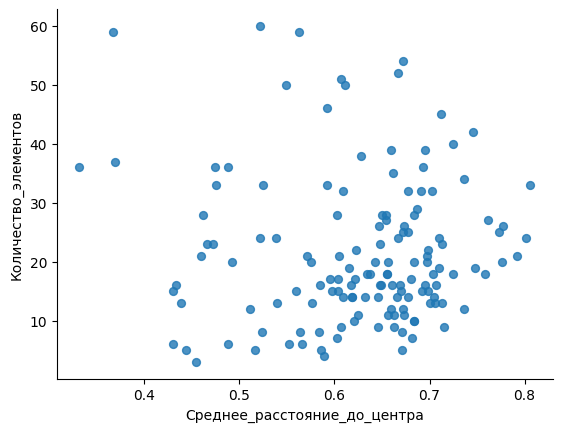

In [ ]:
# @title Среднее_расстояние_до_центра vs Количество_элементов

from matplotlib import pyplot as plt
cluster_density.plot(kind='scatter', x='Среднее_расстояние_до_центра', y='Количество_элементов', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

В левой верхней четверти выделяются несколько наиболее крупных и плотных кластеров.

**Метрика для каждого вопроса**

Для каждого вопроса можно вычислить две метрики:

1. **Расстояние до центроида**. Как далеко вопрос отстоит от центра своего кластера (это уже вычислено в пункте выше).
2. **Расстояние до ближайших 5 соседей в кластере**. Это можно сделать с помощью метода k-nearest neighbors.

In [ ]:
# @title Среднее расстояние до центра и Среднее расстояние до 5 ближайших соседей

from sklearn.neighbors import NearestNeighbors
import numpy as np

# Вычисляем среднее расстояние до ближайших соседей для точек внутри каждого кластера
def compute_nearest_distances(vectors, cluster_labels, n_neighbors=5):
    # Доступ к столбцу 'Кластер', чтобы получить метки кластеров для расчетов
    cluster_ids = cluster_labels['Кластер'].values
    df_clusters['Среднее расстояние до соседей'] = 0.0  # Добавляем столбец для хранения результата
    for cluster in np.unique(cluster_ids):  # Проходим по каждому уникальному кластеру
        # Отбираем только точки, принадлежащие текущему кластеру
        cluster_vectors = vectors[cluster_ids == cluster]
        if len(cluster_vectors) > n_neighbors:
            # Создаем модель для поиска ближайших соседей
            nbrs = NearestNeighbors(n_neighbors=n_neighbors + 1, algorithm='ball_tree').fit(cluster_vectors)
            distances, _ = nbrs.kneighbors(cluster_vectors)  # Находим расстояния до соседей
            # Сохраняем среднее расстояние до ближайших 5 соседей для точек текущего кластера
            df_clusters.loc[cluster_ids == cluster, 'Среднее расстояние до соседей'] = distances[:, 1:].mean(axis=1)
    return df_clusters

# Передаем столбец 'Кластер' в качестве параметра cluster_labels
df_clusters = compute_nearest_distances(vectors, df_clusters[['Кластер']], n_neighbors=5)

# Вывод таблицы с рассчитанными расстояниями до ближайших соседей
print("\033[1;34mТаблица с расстояниями до ближайших соседей:\033[0m\n")
display(df_clusters)

Таблица с расстояниями до ближайших соседей:



,Вопрос,Кластер,Расстояние до центра,Среднее расстояние до соседей
0,Построй план обучения студента по курсу chatGP...,23,0.549412,0.644608
1,что будет изучаться на программе нейронных сет...,41,0.533032,0.649867
2,Что входит в тариф ПРдвинутый?,14,0.448454,0.461141
3,как проходят стажировки?,55,0.322610,0.299263
4,РАсскажи про продвинутый тариф chatGPT,104,0.469166,0.608318
...,...,...,...,...
3051,Какие возможности мы можем дать для графическо...,70,0.786413,1.036411
3052,Эти курсы платные,27,0.627256,0.728392
3053,После курса андроид приложение с нейронной сет...,73,0.753006,0.907855
3054,"Представь, что студент совсем ничего не знает....",31,0.603366,0.751293


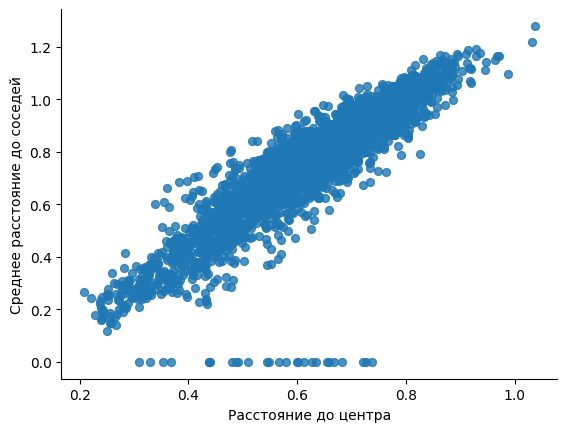

In [ ]:
# @title Среднее расстояние до центра vs Среднее расстояние до соседей

from matplotlib import pyplot as plt
df_clusters.plot(kind='scatter', x='Расстояние до центра', y='Среднее расстояние до соседей', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

Полоса из точек внизу говорит о наличии дублей в базе. Когда расстояние до соседей равно нулю, но при этом такое скопление находится на удалении от центроида.

In [ ]:
# @title Сохранение таблицы расстояний в clusters_with_distanse.xlsx и .csv
# Таблица с расстояниями до ближайших соседей
output_path_variant1 = f'kmeans_variant1_{n_clusters}_with_distanse.xlsx'
df_clusters.to_excel(output_path_variant1, index=False)
df_clusters.to_csv(root_path + 'clusters_with_distanse.csv', index=False)
df_clusters

,Вопрос,Кластер,Расстояние до центра,Среднее расстояние до соседей
0,Построй план обучения студента по курсу chatGP...,23,0.549412,0.644608
1,что будет изучаться на программе нейронных сет...,41,0.533032,0.649867
2,Что входит в тариф ПРдвинутый?,14,0.448454,0.461141
3,как проходят стажировки?,55,0.322610,0.299263
4,РАсскажи про продвинутый тариф chatGPT,104,0.469166,0.608318
...,...,...,...,...
3051,Какие возможности мы можем дать для графическо...,70,0.786413,1.036411
3052,Эти курсы платные,27,0.627256,0.728392
3053,После курса андроид приложение с нейронной сет...,73,0.753006,0.907855
3054,"Представь, что студент совсем ничего не знает....",31,0.603366,0.751293


#### Чекпоинт (загрузка обновленных **clusters**).<br />Среднее расстояние до центра и Среднее расстояние до 5 ближайших соседей.

[Предыдущий чекпоинт](#scrollTo=2woh3rIxXaiR) / [Следующий чекпоинт](#scrollTo=cLT_lDbAVRkj)

In [ ]:
df_clusters = pd.read_csv(root_path + 'clusters_with_distanse.csv', encoding="utf-8")
df_clusters

,Вопрос,Кластер,Расстояние до центра,Среднее расстояние до соседей
0,Построй план обучения студента по курсу chatGP...,23,0.549412,0.644608
1,что будет изучаться на программе нейронных сет...,41,0.533032,0.649867
2,Что входит в тариф ПРдвинутый?,14,0.448454,0.461141
3,как проходят стажировки?,55,0.322610,0.299263
4,РАсскажи про продвинутый тариф chatGPT,104,0.469166,0.608318
...,...,...,...,...
3051,Какие возможности мы можем дать для графическо...,70,0.786413,1.036411
3052,Эти курсы платные,27,0.627256,0.728392
3053,После курса андроид приложение с нейронной сет...,73,0.753006,0.907855
3054,"Представь, что студент совсем ничего не знает....",31,0.603366,0.751293


### Очистка списка от явных дубликатов и схожих вопросов в кластерах методом TF-IDF

**TF-IDF (частота термов и обратная частота документов)** в сочетании с угловой мерой сходства. Этот метод помогает вычислять, насколько тексты похожи друг на друга. Его легко использовать даже на больших наборах данных. Давайте объясним это понятным языком.

---

### 1. **TF-IDF (частота термов и обратная частота документов)**  
Это способ понять, какие слова в тексте важные, а какие — второстепенные.

- **Частота термов (TF)**:  
  Это просто подсчет, сколько раз слово встречается в тексте. Например, в предложении "Как научиться программировать?" слово "как" может встретиться 1 раз, а слово "научиться" — тоже 1 раз. Все просто: чем чаще слово, тем выше его частота.

- **Обратная частота документов (IDF)**:  
  Она оценивает, насколько слово уникально. Если слово встречается почти в каждом тексте (например, "и", "что", "как"), оно теряет свою значимость. А если слово появляется редко (например, "программировать"), оно считается более важным.

**TF-IDF** объединяет эти два показателя. Это как фильтр: он выделяет те слова, которые часто встречаются в одном тексте, но редки в других.

---

### 2. **Угловая мера сходства**  
Чтобы узнать, насколько два текста похожи, мы можем представить их как направления (векторы). Угловая мера помогает оценить, насколько эти направления совпадают.

- Если угол между векторами маленький (почти нет отклонения), тексты очень похожи.  
- Если угол близок к 90°, тексты совсем разные.

**Важно:** значение сходства всегда лежит в диапазоне от 0 до 1:  
- **0** означает, что тексты не имеют ничего общего.  
- **1** означает, что тексты полностью идентичны.  

Примеры:  
- Если значение **0.9**, тексты очень похожи: они используют одни и те же слова или имеют схожую структуру.  
- Если значение **0.5**, тексты пересекаются, но имеют значительные отличия.  
- Если значение **0.1**, тексты почти не связаны.

---

### Как это работает вместе?  

1. **TF-IDF** анализирует тексты, определяя важные слова.  
2. **Угловая мера сходства** сравнивает тексты, оценивая их по важным словам.  
3. На выходе мы получаем число от 0 до 1, которое показывает уровень схожести.

---

### Пример:  
Допустим, у нас есть два вопроса:  
1. "Как научиться программировать?"  
2. "Где можно научиться кодить?"  

- **Шаг 1:** TF-IDF выделяет важные слова: "научиться", "программировать", "кодить".  
- **Шаг 2:** Угловая мера показывает, что слова и их распределение в текстах почти совпадают.  
- **Результат:** Сходство будет около **0.9**, так как вопросы говорят об одном и том же, только с разными формулировками.

---

Этот метод помогает автоматизировать анализ текстов, например, для поиска дублирующихся вопросов или проверки, насколько описание соответствует запросу.

In [ ]:
# Очистим пустые строки, если они есть
data_cleaned = df_clusters[['Вопрос', 'Кластер']].dropna()
data_cleaned

,Вопрос,Кластер
0,Построй план обучения студента по курсу chatGP...,23
1,что будет изучаться на программе нейронных сет...,41
2,Что входит в тариф ПРдвинутый?,14
3,как проходят стажировки?,55
4,РАсскажи про продвинутый тариф chatGPT,104
...,...,...
3051,Какие возможности мы можем дать для графическо...,70
3052,Эти курсы платные,27
3053,После курса андроид приложение с нейронной сет...,73
3054,"Представь, что студент совсем ничего не знает....",31


#### Очистка по всем вопросам всех кластеров

Можно подобрать порог, при котором схожие вопросы с 1 ли 2 ошибками будут удаляться (примеры порога 0.85, 0.8, 0.75, 0.7).

In [ ]:
# @title Очистка методом TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Преобразуем вопросы в векторы с помощью метода TF-IDF
vectorizer = TfidfVectorizer().fit_transform(data_cleaned['Вопрос'])  # Преобразование текста в числовые векторы
tf_vectors = vectorizer.toarray()  # Преобразуем матрицу TF-IDF в массив

# Вычисляем косинусное сходство между всеми вопросами
cosine_sim_matrix = cosine_similarity(tf_vectors)  # Матрица косинусных сходств для всех вопросов

# Понижаем порог сходства до 0.7 и повторяем процесс поиска дубликатов
cosine_sim_threshold_final = 0.7  # Устанавливаем порог сходства

# Поиск дубликатов на основе порога 0.7
duplicates_final_threshold = set()  # Множество для хранения индексов дубликатов
for i in range(len(cosine_sim_matrix)):
    for j in range(i + 1, len(cosine_sim_matrix)):  # Сравниваем только уникальные пары (i < j)
        if cosine_sim_matrix[i][j] > cosine_sim_threshold_final:  # Если сходство выше порога
            duplicates_final_threshold.add(j)  # Добавляем индекс дубликата в множество

# Удаляем дубликаты на основе заданного порога
unique_questions_df = data_cleaned.drop(duplicates_final_threshold).reset_index(drop=True)  # Удаляем строки-дубликаты и сбрасываем индексы

# Сохраняем итоговую таблицу без дубликатов в новый файл
output_file_tfidf_final = 'unique_questions_df_final.xlsx'  # Имя выходного файла
unique_questions_df.to_excel(output_file_tfidf_final, index=False)  # Экспортируем таблицу в Excel

# Вывод имени выходного файла
output_file_tfidf_final  # Вывод пути к файлу в качестве подтверждения

'unique_questions_df_final.xlsx'

In [ ]:
unique_questions_df

,Вопрос,Кластер
0,Построй план обучения студента по курсу chatGP...,23
1,что будет изучаться на программе нейронных сет...,41
2,Что входит в тариф ПРдвинутый?,14
3,как проходят стажировки?,55
4,РАсскажи про продвинутый тариф chatGPT,104
...,...,...
2356,Какие возможности мы можем дать для графическо...,70
2357,Эти курсы платные,27
2358,После курса андроид приложение с нейронной сет...,73
2359,"Представь, что студент совсем ничего не знает....",31


In [ ]:
# @title Сохраняем **unique_questions_df** в кодировке windows-1251

# Функция замены неподдерживаемых символов
def clean_for_windows_1251(text):
    return ''.join([char if char.encode('windows-1251', 'ignore') else '?' for char in text])

# Применяем очистку
unique_questions_df['Вопрос'] = unique_questions_df['Вопрос'].map(clean_for_windows_1251)

# Сохраняем в CSV с кодировкой windows-1251
unique_questions_df.to_csv(
    root_path + 'unique_questions_df_final.csv',
    index=False,
    encoding="windows-1251",
    sep=';'  # Указываем точку с запятой как разделитель
)
print("Файл успешно сохранён в кодировке windows-1251")

Файл успешно сохранён в кодировке windows-1251


## Создание векторной базы **FAISS** (2-я ветка алгоритма) ==> **db_faiss_main**

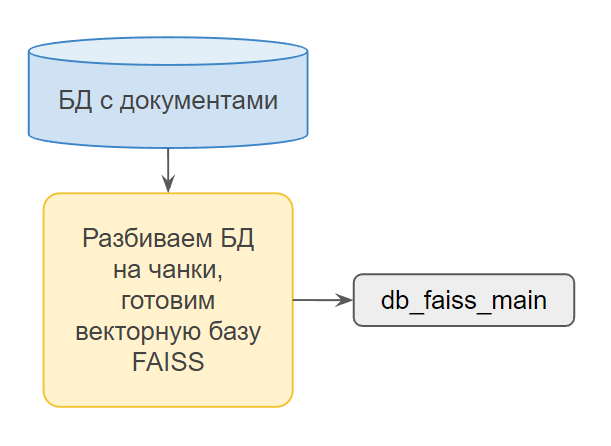

### Нарезка базы на чанки и загрузка таблицы с вопросами

In [ ]:
# @title Подготовка документа, нарезка на чанки, загрузка базы с вопросами

# Функция для векторизации текста
def text_to_vector(text, embeddings):
    return embeddings.embed_documents([text])[0]

# Извлечение последнего номера списка
def extract_last_list_number(md_text):
    matches = re.findall(r"^(\d+)\.", md_text, re.MULTILINE)
    return int(matches[-1]) if matches else None

# Проверка позиции последнего элемента (заголовок или список)
def last_element(md_text):
    headers = [m.start() for m in re.finditer(r"(#{1,6}) .+", md_text)]
    lists = [m.start() for m in re.finditer(r"^(\d+)\.", md_text, re.MULTILINE)]
    return None if not headers and not lists else bool(headers and (not lists or headers[-1] > lists[-1]))

# Извлечение заголовков из текста
def extract_headers(md_text, prev_headers):
    matches = re.findall(r"(#{1,6}) (.+)", md_text)
    if not matches:
        last_number = extract_last_list_number(md_text)
        return prev_headers, None if last_element(md_text) else last_number

    max_level = len(matches[-1][0])
    headers = {k: v for k, v in prev_headers.items() if k < max_level}
    for match in matches:
        level = len(match[0])
        headers[level] = match[1]

    last_number = extract_last_list_number(md_text)
    return headers, None if last_element(md_text) else last_number

# Основная обработка текста
def process_text_file(file_path, len_chunk):
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=len_chunk, chunk_overlap=128)
    source_chunks = []
    prev_headers, item_number = {}, ""

    try:
        loader = TextLoader(file_path, encoding='utf8')
        documents = loader.load()
        for chunk_id, chunk in enumerate(tqdm(text_splitter.split_text(documents[0].page_content))):
            new_headers, last_numerik = extract_headers(chunk, prev_headers)
            prev_headers = copy.deepcopy(new_headers)

            add_hierarchy = " ".join(
                [f'{"#" * level} {header}' for level, header in sorted(prev_headers.items())]
            ) + item_number

            new_chunk = f"{chunk}\nИерархия фрагмента текста в документе: {add_hierarchy}"
            item_number = f" пункт {last_numerik}." if last_numerik is not None else ""

            source_chunks.append(Document(page_content=new_chunk, metadata={'chunk_id': chunk_id}))
    except Exception as e:
        print(f"Ошибка обработки файла {file_path}: {e}")

    return source_chunks

source_chunks = process_text_file(os.path.join(root_path, text_file), len_chunk)
print("Обработка завершена!")

  0%|          | 0/1404 [00:00<?, ?it/s]

Обработка завершена!


In [ ]:
source_chunks[0]

Document(metadata={'chunk_id': 0}, page_content='# Университет Искусственного Интеллекта\n## Описание УИИ\nУниверситет Искусственного Интеллекта - ведущее образовательное учреждение в России, специализирующееся исключительно на области искусственного интеллекта. Он является самым крупным университетом по ИИ в России и странах СНГ, признанным лидером в образовании в сфере ИИ. \nПараллельно с созданием курсов на протяжении пяти лет УИИ активно занимается разработкой в AI-сфере: создает AI-проекты для компаний на заказ.\nУИИ не имеет филиалов за границей.\nКурсы в УИИ проходят студенты по всему миру.\nБолее 4700 студентов со всего мира выбрали УИИ для прохождения курса по AI. Они получают не только теоретические знания, но и активно применяют их в создании проектов по искусственному интеллекту. Благодаря этому, студентами УИИ было создано уже 372 проекта в области ИИ.\nУниверситет также предоставляет консультации более чем 100 крупным и малым компаниям, помогая им реализовывать и внедрять

### Создание векторной базы и подбор 10 релевантных чанков на каждый вопрос

In [ ]:
# @title Создаем базу FAISS

count_tokens = 0

# Если в документе есть содержимое (документ не пуст)
if len(source_chunks):
    # Создаем базу индексов эмбеддингов отрезков документа с использованием FAISS
    # Делим на две части из-за ограничений на количество токенов
    db_faiss_main = FAISS.from_documents(source_chunks[:len(source_chunks)//2], embeddings)
    db_faiss_main_2 = FAISS.from_documents(source_chunks[len(source_chunks)//2:], embeddings)

    # Соединяем индексные базы
    db_faiss_main.merge_from(db_faiss_main_2)

    # Подсчитываем количество токенов в тексте документа
    count_token = num_tokens_from_string(' '.join([x.page_content for x in source_chunks]), "cl100k_base")
    count_tokens += count_token  # Увеличиваем общий счетчик токенов

    # Выводим количество токенов в текущем документе
    print('Количество токенов в документе :', count_token)

    # Сохраняем базу индексов локально в указанную директорию
    db_faiss_main.save_local(os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len_chunk}_large"))

# Получаем цену за обработку одного миллиона токенов для выбранной модели
embed_price = pricing_per_million_tokens_usd.get(model_embed)

# Вычисляем и выводим стоимость запроса на создание базы индексов
print('\nЦЕНА запроса создания базы индексов:', ((int(count_tokens) * embed_price) / 1000000) * usd_price, ' руб.')

Количество токенов в документе : 572066

ЦЕНА запроса создания базы индексов: 6.292726  руб.


 ## Объединение чанков в контекст для кластера вопросов (слияние веток алгоритма)

 ### **unique_questions_df** + **db_faiss_main** ==> **clusters_context**

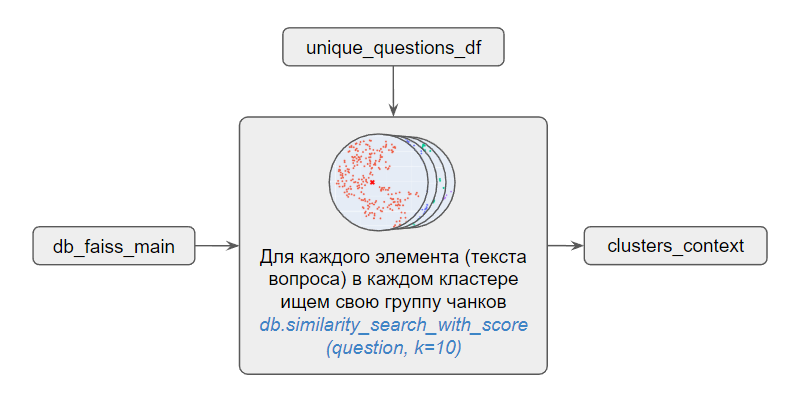

**Этот код выполняет следующие действия:**

1. **Группировка DataFrame по колонке "Кластер"**:
   - Используется метод `groupby` для создания групп на основе значений в колонке `Кластер`. Каждая группа будет содержать строки, у которых одинаковое значение в этой колонке.

2. **Итерация по группам**:
   - Для каждой группы (идентифицированной значением кластера) код:
     - Извлекает список вопросов из колонки `Вопрос` (`group['Вопрос'].tolist()`).
     - Инициализирует пустой список `cluster_context` для хранения результатов обработки вопросов.

3. **Обработка вопросов**:
   - Для каждого вопроса в текущем кластере:
     - Вызывается метод `db_faiss_main.similarity_search_with_score(question, k=10)`, который ищет 10 самых похожих документов в базе данных (предположительно векторной, на основе `FAISS` или аналогичного инструмента).
       - `similarity_search_with_score` возвращает список пар, где каждая пара содержит документ и его оценку схожести.
     - Полученные данные добавляются в список `cluster_context` в виде словаря, который содержит:
       - `question`: сам вопрос.
       - `chunks`: найденные документы с их оценками.
     - Вопрос печатается для отладки или визуального контроля.

4. **Создание словаря для каждого кластера:**
   - По окончании обработки вопросов в каждом кластере, код формирует словарь `clusters_context`. Этот словарь собирает информацию по всем кластерам:
     - Каждый ключ словаря соответствует номеру кластера.
     - Значениями являются списки, где каждый элемент — это словарь с данными по отдельному вопросу:
       - `question`: текст вопроса.
       - `chunks`: список документов, наиболее схожих с вопросом, включая оценку их схожести.


**Пример содержимого словаря `clusters_context`:**

```python
{
    '0': [  # Данные по кластеру номер 0
        {
            'question': 'В курсе продвинутый есть курс по трейдингу?',
            'chunks': [
                (
                    Document(
                        metadata={'chunk_id': 1353},
                        page_content='#### Чем курс по Трейдингу полезен для студентов:\n...'
                    ),
                    0.25998214
                ),
                (
                    Document(
                        metadata={'chunk_id': 1354},
                        page_content='Они также научатся писать собственные бэктесты, ...'
                    ),
                    0.2719795
                ),
                (
                    Document(
                        metadata={'chunk_id': 1352},
                        page_content='### Курс по трейдингу\nСтоимость курса составляет ...'
                    ),
                    0.28200597
                ),
                # ... другие документы
            ]
        },
        # ... другие вопросы в этом кластере
    ],

    '1': [  # Данные по кластеру номер 1
        # ... информация по другим вопросам
    ],
    # ... другие кластеры
}
```

Эта структура данных позволяет эффективно анализировать вопросы и связанные с ними документы внутри каждого кластера, упрощая поиск информации и анализ текстовых данных.

In [ ]:
# @title Чекпоинт (загрузка баз **FAISS (db_faiss_main)** и **unique_questions_df**) <br />[Предыдущий чекпоинт](#scrollTo=c1SB0Au-xn5e) / [Следующий чекпоинт](#scrollTo=ELafK3chcmE9)

from langchain.vectorstores import FAISS

# Загрузка уникальных вопросов из CSV
def load_unique_questions_csv(file_path):
    df = pd.read_csv(file_path, encoding='windows-1251', delimiter=';')
    return df['Вопрос'].tolist(), df

# Путь к директории с сохраненной базой
index_file_path = os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len_chunk}_large")

# Загрузка базы индексов из локального файла с разрешением опасной десериализации
try:
    db_faiss_main = FAISS.load_local(index_file_path, embeddings=embeddings, allow_dangerous_deserialization=True)
    print(f"База данных успешно загружена из: {index_file_path}")
except Exception as e:
    print(f"Ошибка загрузки базы данных: {e}")

# Загрузка вопросов и их DataFrame
file_path = root_path + 'unique_questions_df_final.csv'
unique_questions, unique_questions_df = load_unique_questions_csv(file_path)

База данных успешно загружена из: /faiss_index/base_uii_edit_22_1024_large


In [ ]:
# @title Группировка списка вопросов по кластерам и получение релевантных чанков к каждому вопросу

# Инициализация словаря для хранения информации по кластерам
clusters_context = {}

# Группируем DataFrame по колонке 'Кластер'
grouped_df = unique_questions_df.groupby('Кластер')

# Перебираем группы в сгруппированном DataFrame
for cluster, group in grouped_df:
    cluster_context = []  # Список для хранения информации по текущему кластеру

    # Получаем список вопросов из колонки 'Вопрос' для текущей группы
    questions = group['Вопрос'].tolist()

    # Выводим информацию о текущем кластере с цветовым акцентом
    print(f"\033[1;34mКластер {cluster}\033[0m")
    print("\033[1;30m" + "-" * 50 + "\033[0m")  # Разделитель

    # Обрабатываем каждый вопрос из текущего кластера
    for question in questions:
        # Ищем похожие документы для текущего вопроса, ограничение - 10 лучших совпадений
        sim_docs = db_faiss_main.similarity_search_with_score(question, k=10)

        # Считаем краткую информацию по документам
        doc_count = len(sim_docs)  # Количество найденных документов
        avg_score = sum(score for _, score in sim_docs) / doc_count if doc_count > 0 else 0  # Средний score

        # Добавляем информацию о вопросе и найденных фрагментах в список текущего кластера
        cluster_context.append({'question': question, 'chunks': sim_docs})

        # Выводим информацию о текущем вопросе с краткой статистикой в одну строку
        print(f"  \033[1;36mВопрос:\033[0m {question} | "
              f"\033[1;32mНайдено документов:\033[0m {doc_count} | "
              f"\033[1;36mСредний score:\033[0m {avg_score:.2f}")

    print("\033[1;30m" + "=" * 50 + "\033[0m")  # Разделитель для завершения кластера

    # Добавляем информацию о текущем кластере в общий словарь
    clusters_context[cluster] = cluster_context

Кластер 0
--------------------------------------------------
  Вопрос: В курсе продвинутый есть курс по трейднигу? | Найдено документов: 10 | Средний score: 0.31
  Вопрос: состав курса базовый | Найдено документов: 10 | Средний score: 0.31
  Вопрос: на какое время рассчитан курс продвинутый | Найдено документов: 10 | Средний score: 0.32
  Вопрос: Программа курса Продвинутый курс по интеграции в Production | Найдено документов: 10 | Средний score: 0.24
  Вопрос: как в бизнесе могут помочь знания курса уровень базовый? | Найдено документов: 10 | Средний score: 0.30
  Вопрос: что включает в себя курс Ai под ключ | Найдено документов: 10 | Средний score: 0.29
  Вопрос: курс по интеграции в production для чего он | Найдено документов: 10 | Средний score: 0.30
  Вопрос: Обьясни простыми словами, что изучается на курсе по Пай Торч | Найдено документов: 10 | Средний score: 0.32
  Вопрос: нужен продвинутый курс | Найдено документов: 10 | Средний score: 0.32
  Вопрос: что входит в экспресс курс 

In [ ]:
# Отображаем все вопросы по первому Кластеру и их найденные чанки
clusters_context[0]

[{'question': 'В курсе продвинутый есть курс по трейднигу?',
  'chunks': [(Document(metadata={'chunk_id': 1353}, page_content='#### Чем курс по Трейдингу полезен для студентов:\nГлавная цель данного курса - обучить участников созданию собственных инструментов для анализа движения акций и принятия правильных решений. В рамках курса студенты научатся использовать готовые инструменты, а также создавать собственную экспериментальную площадку на своем компьютере для проверки и оптимизации стратегий. \nЭтот курс будет полезен студентам, которые интересуются трейдингом и хотят научиться анализировать движение акций и принимать правильные решения. Студенты научатся использовать готовые инструменты и создавать собственную экспериментальную платформу на компьютере для тестирования и оптимизации торговых стратегий. \nОни узнают, как работать с внешними источниками для поиска и загрузки данных, использовать библиотеки для бэктестинга, создавать пользовательские функции для отображения данных и пис

In [ ]:
# @title Сохраняем **clusters_context**

import pickle

# Сохранение объекта в файл
with open(root_path + 'clusters_context.pkl', 'wb') as f:
    pickle.dump(clusters_context, f)

print(f"Данные успешно сохранены в {root_path}clusters_context.pkl")

Данные успешно сохранены в /content/local_data/clusters_context.pkl


## Фильтрация чанков всех вопросов кластера по частоте встречаемости при пороге 20%

In [ ]:
# @title Чекпоинт (загрузка **clusters_context** из файла)<br />[Предыдущий чекпоинт](#scrollTo=cLT_lDbAVRkj) / [Следующий чекпоинт](#scrollTo=FyP9Qxr6SY5u)

with open(root_path + 'clusters_context.pkl', 'rb') as f:
    clusters_context = pickle.load(f)
print("Данные успешно загружены из clusters_context.pkl")

Данные успешно загружены из clusters_context.pkl


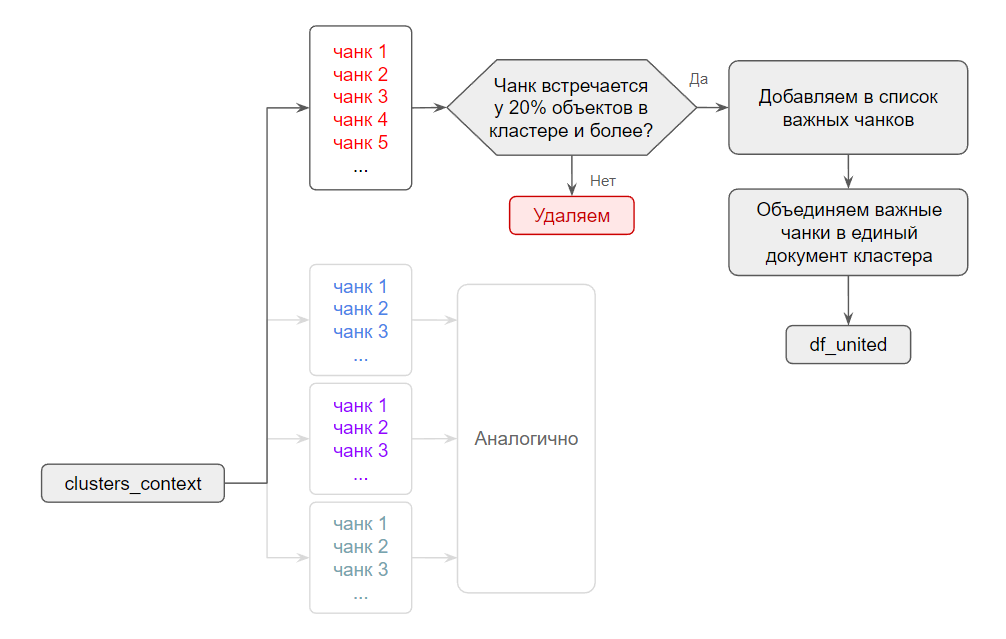

In [ ]:
len(clusters_context)

142

### Фильтрация чанков. Основные моменты:
1. **Цели кода:**
   - Подсчитать количество отфильтрованных и неотфильтрованных чанков для каждого кластера.
   - Сохранить объединенную информацию о чанках и связанных с ними вопросах.

2. **Ключевые переменные:**
   - `chunk_counter`: подсчет частот каждого `chunk_id` в текущем кластере.
   - `filtered_chunk_ids`: идентификаторы чанков, которые встречаются более чем в 20% вопросов.
   - `filtered_data`: информация для создания DataFrame.
   - `united_chunks_clusters`: текстовая информация для каждого кластера.

3. **Результаты:**
   - `filtered_df`: DataFrame с подробной информацией о каждом кластере.
   - `united_chunks_clusters`: текстовые данные, сгруппированные по кластерам.

In [ ]:
# @title Фильтрация чанков всех вопросов кластера по частоте встречаемости при пороге 20%

import pandas as pd
import collections

# Храним данные по всем кластерам
all_filtered_counts = []  # Список для хранения количества отфильтрованных чанков для каждого кластера
all_not_filtered_counts = []  # Список для хранения количества неотфильтрованных чанков для каждого кластера
filtered_data = []  # Список для хранения структурированной информации по кластерам
united_chunks_clusters = []  # Список для объединенной информации по кластерам

# Основной процесс обработки данных
for cluster, chunks_data in clusters_context.items():
    # Подсчет частот chunk_ids
    chunk_counter = collections.Counter(
        chunk[0].metadata.get('chunk_id')  # Безопасное извлечение chunk_id из метаданных
        for data in chunks_data  # Для каждого вопроса в текущем кластере
        for chunk in data['chunks']  # Для каждого чанка, связанного с вопросом
        if 'chunk_id' in chunk[0].metadata  # Убедимся, что chunk_id присутствует в метаданных
    )

    # Общее количество уникальных чанков
    total_chunks = len(chunk_counter)

    # Фильтрация по частоте появления
    filtered_chunk_ids = [
        chunk_id for chunk_id, count in chunk_counter.items()
        if len(chunks_data) > 0 and count / len(chunks_data) > 0.20
    ]

    # Подсчет отфильтрованных и неотфильтрованных чанков
    filtered_count = len(filtered_chunk_ids)
    not_filtered_chunk_ids = [
        chunk_id for chunk_id in chunk_counter.keys()
        if chunk_id not in filtered_chunk_ids
    ]
    not_filtered_count = len(not_filtered_chunk_ids)

    all_filtered_counts.append(filtered_count)
    all_not_filtered_counts.append(not_filtered_count)

    # Сохранение информации для DataFrame
    filtered_data.append({
        'cluster': cluster,
        'total_chunks': total_chunks,
        'filtered_chunks': filtered_count,
        'not_filtered_chunks': not_filtered_count,
        'filtered_chunk_ids': filtered_chunk_ids
    })

    # Сбор текста отфильтрованных чанков
    filtered_text_chunks = []  # Список для текста отфильтрованных чанков
    joined_questions = []  # Список для всех вопросов, связанных с текущим кластером
    added_chunks = set()  # Множество для отслеживания добавленных chunk_id (чтобы избежать дублирования)

    for data in chunks_data:
        joined_questions.append(data['question'])  # Добавляем вопрос в общий список вопросов кластера
        for chunk in data['chunks']:
            chunk_id = chunk[0].metadata.get('chunk_id')  # Безопасное извлечение chunk_id
            if chunk_id and chunk_id in filtered_chunk_ids and chunk_id not in added_chunks:
                filtered_text_chunks.append(chunk[0].page_content)  # Добавляем текст чанка в список
                added_chunks.add(chunk_id)  # Помечаем chunk_id как добавленный

    # Объединение данных для текущего кластера
    united_chunks_clusters.append({
        'cluster': cluster,
        'questions': '\n'.join(joined_questions) if joined_questions else 'Нет вопросов',
        'unified_text': '\n'.join(filtered_text_chunks) if filtered_text_chunks else 'Нет текста',
        'len_filtered_chunk': len(filtered_chunk_ids),
        'total_chunks': total_chunks
    })

# Создаем DataFrame из отфильтрованных данных
filtered_df = pd.DataFrame(filtered_data)

# DataFrame filtered_df содержит всю собранную информацию о кластерах, включая общее количество чанков,
# количество отфильтрованных и неотфильтрованных чанков, а также списки отфильтрованных chunk_id.

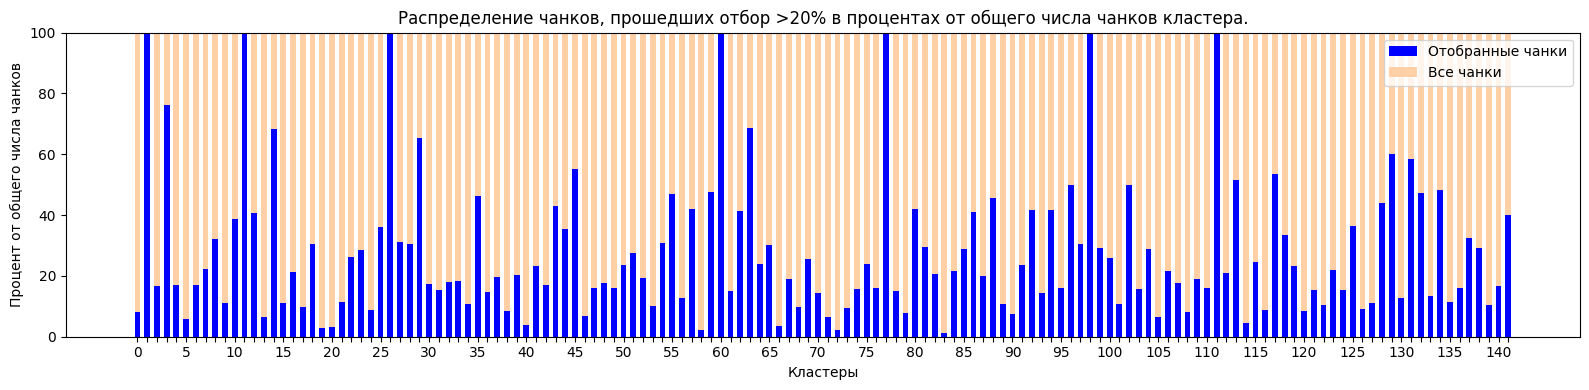

In [ ]:
# @title Визуализация данных

import matplotlib.pyplot as plt

# Подготовка данных для визуализации
clusters = [data['cluster'] for data in filtered_data]
filtered_counts = [data['filtered_chunks'] for data in filtered_data]
not_filtered_counts = [data['not_filtered_chunks'] for data in filtered_data]
total_chunks = [data['total_chunks'] for data in filtered_data]

# Вычисление процентного распределения
relative_filtered_counts = [
    (filtered / total) * 100 if total > 0 else 0
    for filtered, total in zip(filtered_counts, total_chunks)
]
relative_not_filtered_counts = [
    (not_filtered / total) * 100 if total > 0 else 0
    for not_filtered, total in zip(not_filtered_counts, total_chunks)
]

# Настройка меток для кластеров
labels = [str(i) if (i % 5 == 0) else '' for i in range(len(clusters))]

# Построение диаграммы
fig, ax = plt.subplots(figsize=(16, 4))

bar_width = 0.6
x = range(len(labels))

# Отображение данных на диаграмме
ax.bar(x, relative_filtered_counts, bar_width, label='Отобранные чанки', color='blue')
ax.bar(x, relative_not_filtered_counts, bar_width, bottom=relative_filtered_counts, label='Все чанки', color='#ffd0a6')

# Настройки графика
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, fontsize=10)
ax.set_xlabel('Кластеры')
ax.set_ylabel('Процент от общего числа чанков')
ax.set_title('Распределение чанков, прошедших отбор >20% в процентах от общего числа чанков кластера.')
ax.legend()

# Отображение графика
plt.tight_layout()
plt.show()


In [ ]:
# @title Отображение **filtered_df** с результатами

display(filtered_df)

,cluster,total_chunks,filtered_chunks,not_filtered_chunks,filtered_chunk_ids
0,0,135,11,124,"[1354, 429, 938, 1326, 1327, 128, 1013, 1402, ..."
1,1,13,13,0,"[720, 724, 99, 713, 1270, 723, 1162, 255, 1153..."
2,2,60,10,50,"[54, 33, 719, 298, 1061, 1063, 245, 49, 46, 1200]"
3,3,21,16,5,"[1268, 1318, 281, 1302, 1272, 1301, 1278, 1294..."
4,4,41,7,34,"[1271, 1155, 1167, 474, 1088, 1092, 1170]"
...,...,...,...,...,...
137,137,37,12,25,"[342, 1174, 340, 829, 831, 226, 1175, 435, 345..."
138,138,48,14,34,"[298, 245, 279, 62, 54, 345, 344, 277, 400, 68..."
139,139,87,9,78,"[936, 336, 219, 238, 277, 180, 282, 248, 91]"
140,140,42,7,35,"[220, 394, 300, 774, 226, 418, 345]"


In [ ]:
# @title Вывод первых 100 символов объединенного текста для каждого кластера (из **united_chunks_clusters**)
for cluster_data in united_chunks_clusters:
    print(f"\033[1;34mКластер {cluster_data['cluster']} (первые 100 символов):\033[0m")
    print(f"{cluster_data['unified_text'][:100]}\n")

Кластер 0 (первые 100 символов):
Они также научатся писать собственные бэктесты, использовать генетический алгоритм для разбивки данн

Кластер 1 (первые 100 символов):
## Доступность курса  ChatGPT Professional для людей без опыта программирования
У нас суммарно больш

Кластер 2 (первые 100 символов):
## Как найти время на прохождение курсов:
Гибкая система занятий УИИ позволяет студентам проходить к

Кластер 3 (первые 100 символов):
### Тарифы курса "ChatGPT Professional New":
1. Тариф LIGHT: 149 900
Состав тарифа:
    - 30 живых з

Кластер 4 (первые 100 символов):
Компаниям необходимы специалисты, которые могут дообучать нейронную сеть на внутренней базе данных. 

Кластер 5 (первые 100 символов):
3. Курс по данным (14 занятий);
4. Курс по PyTorch (10 занятий);
5. Курс по продвинутой интеграции в

Кластер 6 (первые 100 символов):
хотят получать деньги, но боятся брать на себя ответственность. В таком случае сложно стать ценным с

Кластер 7 (первые 100 символов):
У нас также есть канал

In [ ]:
df_united = pd.DataFrame(united_chunks_clusters)
df_united.head()

,cluster,questions,unified_text,len_filtered_chunk,total_chunks
0,0,В курсе продвинутый есть курс по трейднигу?\nс...,Они также научатся писать собственные бэктесты...,11,135
1,1,"Чем ваш курс chatGPT Professional лучше, чем у...",## Доступность курса ChatGPT Professional для...,13,13
2,2,Что значит гибкий график занятий\nОбучение буд...,## Как найти время на прохождение курсов:\nГиб...,10,60
3,3,Расскажи про наш базовый тариф\nРасскажи подро...,"### Тарифы курса ""ChatGPT Professional New"":\n...",16,21
4,4,нейро-консультант работает на базе chatGPT? Ис...,"Компаниям необходимы специалисты, которые могу...",7,41


In [ ]:
# Быстро проверяем аномалии в количестве отфильтрованных чанков. Нули, отрицательные и слишком большие значения
df_united['len_filtered_chunk'].unique()

array([11, 13, 10, 16,  7, 14, 12, 19, 15,  3,  5,  9, 18, 26, 20, 17,  6,
        4, 28,  8,  2])

In [ ]:
for i in range(len(df_united)):
  print(num_tokens_from_string(df_united['unified_text'][i], "cl100k_base"))

4244
4825
4214
6468
2560
2634
2066
3664
3065
5173
5359
7979
5983
5091
5331
3743
5276
4790
7258
1061
2410
4392
6627
4871
3967
6721
9486
8105
4538
7395
4398
3708
3420
3731
2746
4922
5966
3995
2862
5447
2031
6697
5710
6209
3640
6230
3830
4167
4549
4633
4230
6732
3654
3866
5700
6209
4436
5461
1773
3634
10982
2625
7444
4398
3684
7601
2227
5524
3577
5099
3191
4451
1377
5013
4433
5008
4139
11076
3250
2608
5232
6015
5175
401
5106
5097
6641
6151
5268
5001
3901
6321
8293
4646
7059
4066
7038
6902
8127
6118
4889
4729
3698
4940
7659
2398
3701
5334
2426
2850
5801
4694
5410
6797
2401
4674
3949
5817
5422
5458
2947
5538
3532
5060
5119
4430
3767
3812
6128
4286
4121
5627
7676
4898
4937
5348
6504
3788
4735
2698
2449
4940


In [ ]:
df_united.to_excel(root_path + 'df_united.xlsx', index=False)
df_united.to_csv(root_path + 'df_united.csv', index=False, encoding='utf-8')

## Фильтруем и структурируем единые документы при помощи OpenAI

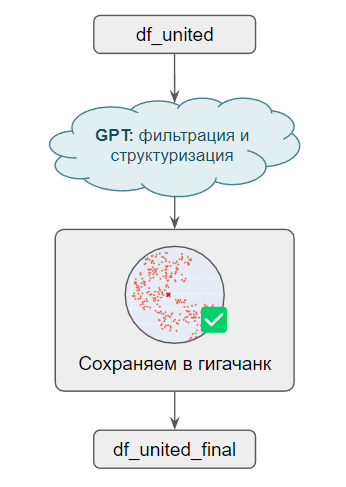

In [ ]:
# @title Чекпоинт (загрузка **df_united** из файла)<br />[Предыдущий чекпоинт](#scrollTo=ELafK3chcmE9) / [Следующий чекпоинт](#scrollTo=qqPA0q-VX56C)

file_path = root_path + 'df_united.csv'
df_united = pd.read_csv(file_path, encoding='utf-8')

In [ ]:
# @title Многопоточные функции запросов к OpenAI (для ускорения обработки)

import concurrent.futures
import openai
import pandas as pd

def chunk_summary(text):
    # Формируем промпты для суммаризации
    messages = [
        {"role": "system",
         "content": "Вы выдающийся методолог Базы Знаний компании Университета Искусственного Интеллекта(УИИ), "
                    "с познаниями в области искусственного"
                    "интеллекта и машинного обучения.\nВаша задача — объединить фрагменты из базы знаний в один документ. "
                    "Для этого необходимо их проанализировать, логически структурировать, убрать дубликаты. Ничего от себя не придумывай, используй только информацию из фрагментов базы знаний"},
        {"role": "user",
         "content": f"Пожалуйста объедините фрагменты из базы знаний в один документ.\n\nВАЖНО: не нужно придумывать то что не написано или отсутствует в "
                    f"фрагментах базы знаний).\n\nФрагменты базы знаний:\n\n{text}"}
    ]
    # Генерация суммаризации с помощью API OpenAI
    client = openai.OpenAI()
    completion = client.chat.completions.create(
        model=model_answer,
        messages=messages,
        temperature=0.1,
        # max_tokens=8000,
        seed=43,
    )
    cost_details = calculate_cost(completion, usd_price)
    history_cost.append({'chunk_summary': cost_details})
    # Извлечение текста суммаризации из ответа
    summary = completion.choices[0].message.content
    return summary

def process_chunk_in_parallel(df, max_threads=10):
    # Используем ThreadPoolExecutor с заданным количеством потоков
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_threads) as executor:
        # Применяем функцию chunk_summary параллельно ко всем строкам колонки
        results = list(executor.map(chunk_summary, df['unified_text']))

    # Создаем новую колонку summary с результатами
    df['summary'] = results
    return df

In [ ]:
# @title Применяем функцию для параллельной обработки всех данных

# Установите нужное значение max_threads для оптимального количества потоков
df_united_final = process_chunk_in_parallel(df_united, max_threads=20)

# Просмотрим результат
df_united_final.head()

,cluster,questions,unified_text,len_filtered_chunk,total_chunks,summary
0,0,В курсе продвинутый есть курс по трейднигу?\nс...,Они также научатся писать собственные бэктесты...,11,135,# Университет Искусственного Интеллекта\n\n## ...
1,1,"Чем ваш курс chatGPT Professional лучше, чем у...",## Доступность курса ChatGPT Professional для...,13,13,# Университет Искусственного Интеллекта\n\n## ...
2,2,Что значит гибкий график занятий\nОбучение буд...,## Как найти время на прохождение курсов:\nГиб...,10,60,# Университет Искусственного Интеллекта\n\n## ...
3,3,Расскажи про наш базовый тариф\nРасскажи подро...,"### Тарифы курса ""ChatGPT Professional New"":\n...",16,21,# Университет Искусственного Интеллекта\n\n## ...
4,4,нейро-консультант работает на базе chatGPT? Ис...,"Компаниям необходимы специалисты, которые могу...",7,41,# Университет Искусственного Интеллекта\n\n## ...


In [ ]:
# @title Сохраняем **==* Гигачанки *==**

df_united_final.to_excel('df_united_final.xlsx', index=False)
df_united_final.to_csv(root_path + 'df_united_final.csv', index=False)

# Преобразуем history_cost в DataFrame перед сохранением в CSV
history_cost_df = pd.DataFrame(history_cost)

# Сохраняем в CSV
history_cost_df.to_csv(root_path + 'history_cost.csv', index=False)

# Производим несколько запросов к OpenAI

In [ ]:
# @title Чекпоинт (загрузка **df_united_final**, **vectors** и **df_clusters** из файлов)<br />[Предыдущий чекпоинт](#scrollTo=FyP9Qxr6SY5u)

# Загрузка объединённого DataFrame
united_file_path = os.path.join(root_path, 'df_united_final.csv')
if not os.path.exists(united_file_path):
    raise FileNotFoundError(f"Файл df_united_final.csv не найден по пути: {united_file_path}")
df_united_final = pd.read_csv(united_file_path, encoding='utf-8')
print(f"Файл объединённого DataFrame загружен: {united_file_path}, строк: {len(df_united_final)}")

# Загрузка векторов
vectors_file_path = os.path.join(root_path, 'vectors.npy')
if not os.path.exists(vectors_file_path):
    raise FileNotFoundError(f"Файл vectors.npy не найден по пути: {vectors_file_path}")
with open(vectors_file_path, 'rb') as f:
    vectors = np.load(f)
    print(f"Векторы успешно загружены: {vectors_file_path}, размер: {vectors.shape}")

# Загрузка кластеров
clusters_file_path = os.path.join(root_path, 'clusters.csv')
if not os.path.exists(clusters_file_path):
    raise FileNotFoundError(f"Файл clusters.csv не найден по пути: {clusters_file_path}")
df_clusters = pd.read_csv(clusters_file_path, encoding='utf-8')
print(f"Кластеры загружены: {clusters_file_path}, строк: {len(df_clusters)}")


Файл объединённого DataFrame загружен: /content/local_data/df_united_final.csv, строк: 142
Векторы успешно загружены: /content/local_data/vectors.npy, размер: (3056, 3072)
Кластеры загружены: /content/local_data/clusters.csv, строк: 3056


In [ ]:
# @title Функция для работы с OpenAI

def answer_gpt(question, chunks_text, model_answer):
    system_prompt = (
        "Ты - профессиональный менеджер Университета Искусственного Интеллекта (УИИ). Ответь на вопрос пользователя используя прилагаемые фрагменты документов.\n"
        "Отвечай кратко и по существу. Ответ не должен превышать 4000 символов.\n"
        "Тебе запрещено упоминать о предоставленных фрагментах документов.\n"
    )

    user_prompt_template = (
        "Используй документ для формирования ответа пользователю.\n"
        "ВАЖНО: не нужно придумывать то что не написано или отсутствует в фрагментах базы знаний).\n"
        "Вопрос пользователя: {question}\n\n"
        "Фрагменты базы знаний:\n{chunks_text}\n\n"
    )

    user_prompt = user_prompt_template.format(
        question=question,
        chunks_text=chunks_text,
    )

    # Формируем запрос
    messages = [
        {"role": "system",
         "content": system_prompt},
        {"role": "user",
         "content": user_prompt}
    ]
    # Генерация ответа с помощью API OpenAI
    client = openai.OpenAI()
    completion = client.chat.completions.create(
        model=model_answer,
        messages=messages,
        temperature=0.0,
        # max_tokens=2000,
    )
    cost_details = calculate_cost(completion, usd_price)

    return {
        'question': question,
        'answer': completion.choices[0].message.content,
        'cost_details': cost_details,
    }

### Классический вариант. Создаем эмбеддинги с помощью FAISS

In [ ]:
# @title Создаем базу FAISS. Вариант, где вектор - все вопросы кластера
united_chunks = []
count_tokens = 0

for row in df_united_final.itertuples():
  cluster = row.cluster
  questions = row.questions
  summary = row.summary
  united_chunks.append(Document(page_content=questions, metadata={'cluster': cluster, 'summary': summary}))

# Если документ не пуст, то создать и сохранить базу индексов эмбеддингов отрезков документа
if len(united_chunks):
    db_united = FAISS.from_documents(united_chunks, embeddings)
    count_token = num_tokens_from_string(' '.join([x.page_content for x in united_chunks]), "cl100k_base")
    count_tokens += count_token
    print('Количество токенов в документе :', count_token)

    # Сохраняем базу индексов локально в указанную директорию
    save_path = os.path.join(root_path, db_index_path, f"{os.path.splitext(text_file)[0]}_{len_chunk}_summary_large")
    db_united.save_local(save_path)

embed_price = pricing_per_million_tokens_usd.get(model_embed)
print('\nЦЕНА запроса создания базы индексов:', ((int(count_tokens) * embed_price) / 1000000) * usd_price, ' руб.')
print('\nЦЕНА генерации summary:', calculate_total_cost(history_cost))

Количество токенов в документе : 54152

ЦЕНА запроса создания базы индексов: 0.5956720000000001  руб.

ЦЕНА генерации summary: Общая стоимость вызовов для запроса: 21.86342 руб


In [ ]:
# @title ОСНОВНОЙ ЦИКЛ ВОПРОСОВ. Классический вариант.

questions = [
    'Как научиться программировать под GPT?',
    'Мне посоветовали стать программистом. Что ты знаешь об этом?',
    'Как работает градиентный спуск?',
    'Сколько стоит рыба?',
    'ИИ что это?',
]

current_base = None

for question in questions:
    print("---- ---- ---- ---- ---- ---- ---- ----\n\033[1;034mВопрос:\033[0m", question)
    # Выполняем поиск
    doc = db_united.similarity_search(question, k=1)
    cluster_number = doc[0].metadata['cluster']  # Это найденный кластер
    print("\033[1;034mКластер:\033[0m", cluster_number)
    summary = doc[0].metadata['summary']
    answer = answer_gpt(question, summary, model_answer)
    print("\033[1;035mОтвет:\033[0m", answer['answer'], '\n')

---- ---- ---- ---- ---- ---- ---- ----
Вопрос: Как научиться программировать под GPT?
Кластер: 84
Ответ: Чтобы научиться программировать под GPT, вы можете рассмотреть курс "ChatGPT Professional" в Университете Искусственного Интеллекта. Этот курс предлагает доступные элементы программирования на Python, которые помогут вам освоить основы. 

Курс включает 30 живых занятий и 15 записанных, охватывающих темы, такие как работа с библиотеками, создание веб-сервисов и Telegram-ботов. Также предусмотрены стажировки с ведущими компаниями, что позволит вам применить полученные знания на практике.

Если у вас нет опыта в программировании, не переживайте — курс подходит для людей с разным уровнем подготовки, включая тех, кто не имеет технического образования. Вы сможете развить необходимые навыки и подготовиться к работе с ChatGPT, что станет важным требованием на рынке труда. 

---- ---- ---- ---- ---- ---- ---- ----
Вопрос: Мне посоветовали стать программистом. Что ты знаешь об этом?
Кластер:


##### 1) «FAISS по гигачанкам» (один вектор на кластер)

**Идея.** делаем по одному документу на кластер, где `page_content` — склеенные ВСЕ вопросы кластера. Дальше:

* `FAISS.from_documents(united_chunks, embeddings)` → 1 эмбеддинг на кластер (гигачанк).
* На запрос: `db_united.similarity_search(question, k=1)` → ближайши гигачанк ⇒ её `metadata['cluster']`, `metadata['summary']`.

**Семантика сопоставления.**

* Вектор кластера = эмбеддинг *длинного текста* (конкатенация вопросов). Модель выдаёт один «усреднённый» смысловой вектор кластера.
* Сходство запроса считается к ЭТОМУ усреднённому вектору. По сути, вы ищете ближайший **центроид-like** (но построенный не усреднением векторов, а эмбеддингом длинного текста).

**Плюсы.**

* Очень дёшево и быстро на инференсе: один кандидат на кластер, `k=1`.
* Мало эмбеддингов в хранилище (≈ #кластеров), легко сохранять/грузить FAISS.
* Дёшево на построении, если кластеров мало (эмбеддинг длиннее, но их немного).

**Минусы и риски.**

* Конкатенация может **превысить лимит токенов** эмбеддера → усечёный ввод, потеря «хвоста».
* Даже без усечения, длинные тексты часто дают «размытую» репрезентацию: специфические подтемы кластера могут **раствориться**.
* Кластер выбирается по одному гига-вектору ⇒ **нет голосования соседей**, нет устойчивости к локальным синонимам.
* Параметр `k=1` + отсутствие порога сходства ⇒ нет «отказа» при OOD-вопросах.







### Альтернативный вариант. Поиск по кластеру.

В данном блоке мы производим подбор гигачанка на основе попадания вопроса в кластер. Т.е. векторизация df_united_final при помощи FAISS OpenAIEmbeddings и дальнейший поиск в эмбеддингах не производится. Вместо этого, мы осуществляем поиск по кластеру.

In [ ]:
# @title Функции поиска кластера и гигачанка

import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize
from collections import Counter

def find_cluster_for_question(new_question, embeddings_model, vectors, df_clusters, n_neighbors=5):
    """
    Находит кластер для нового вопроса на основе ближайших соседей.

    :param new_question: Строка с новым вопросом.
    :param embeddings_model: Модель для генерации эмбеддингов.
    :param vectors: numpy массив эмбеддингов всех вопросов.
    :param df_clusters: DataFrame с колонками "Вопрос" и "Кластер".
    :param n_neighbors: Количество ближайших соседей для анализа.
    :return: Номер наиболее частого кластера среди ближайших соседей.
    """
    # Генерация эмбеддинга для нового вопроса
    question_vector = np.array(embeddings_model.embed_query(new_question)).reshape(1, -1)

    """
    Если исходные векторы не нормализованы, использование косинусного расстояния (углового сходства)
    в методе NearestNeighbors с параметром metric='cosine' всё равно будет работать корректно.
    Это связано с тем, что косинусное расстояние (или сходство)
    автоматически учитывает нормализацию векторов, поскольку оно основано
    на угле между ними, а не на их длине.

    Однако, если вы планируете использовать другие метрики, такие как Евклидово расстояние
    (metric='euclidean'), нормализация потребуется, чтобы устранить влияние масштаба векторов.
    """
    # Нормализация векторов (если необходимо для других метрик)
    vectors_normalized = normalize(vectors, axis=1, norm='l2')  # Это L2. не путать с цифрой 12
    question_vector_normalized = normalize(question_vector, axis=1, norm='l2')
    """
    Пояснение параметров:
        axis=1: Каждая строка в массиве обрабатывается независимо, то есть нормализация применяется к каждому вектору отдельно.
                Например, если vectors — это матрица эмбеддингов, каждая строка представляет вектор одного объекта, и нормализация масштабирует этот вектор.
        norm='l2': Это тип нормализации, где каждый вектор преобразуется так, чтобы его L2-норма (длина вектора) равнялась 1.
    """

    # Поиск ближайших соседей
    knn = NearestNeighbors(n_neighbors=n_neighbors, metric='cosine')
    knn.fit(vectors_normalized)  # Используем нормализованные векторы
    distances, indices = knn.kneighbors(question_vector_normalized)

    # Получение кластеров ближайших соседей
    neighbor_clusters = df_clusters.iloc[indices.flatten()]['Кластер'].values

    # Определение наиболее часто встречающегося кластера
    most_common_cluster = Counter(neighbor_clusters).most_common(1)[0][0]
    return most_common_cluster


def find_cluster(question):
    cluster_number = find_cluster_for_question(
        new_question=question,
        embeddings_model=embeddings_large,  # Модель для эмбеддингов
        vectors=vectors,  # Эмбеддинги всех вопросов
        df_clusters=df_clusters,  # Таблица с вопросами и кластерами
        n_neighbors=5  # Количество ближайших соседей
    )
    return cluster_number


def get_summary_by_cluster(df_united_final, cluster_number):
    """
    Извлекает summary для указанного номера кластера.

    :param df_united_final: DataFrame, содержащий данные кластеров. Гигачанки.
    :param cluster_number: Номер кластера, для которого нужно получить summary.
    :return: Summary кластера (строка) или сообщение, если кластер отсутствует.
    """
    # Фильтруем DataFrame по номеру кластера
    cluster_row = df_united_final.loc[df_united_final['cluster'] == cluster_number]

    if cluster_row.empty:
        return f"Кластер {cluster_number} не найден."

    # Извлекаем summary
    return cluster_row['summary'].iloc[0]



# Пример использования
# question = "Как научиться программировать под GPT?"
# cluster_number = find_cluster(question)
# print(f"Новый вопрос относится к кластеру: {cluster_number}")
#
# summary = get_summary_by_cluster(df_united_final, cluster_number)
# print(summary)

In [ ]:
# @title ОСНОВНОЙ ЦИКЛ ВОПРОСОВ. Альтернативный вариант.

questions = [
    'Как научиться программировать под GPT?',
    'Мне посоветовали стать программистом. Что ты знаешь об этом?',
    'Как работает градиентный спуск?',
    'Сколько стоит рыба?',
    'ИИ что это?',
]

current_base = None

for question in questions:
    print("---- ---- ---- ---- ---- ---- ---- ----\n\033[1;034mВопрос:\033[0m", question)
    cluster_number = find_cluster(question)
    print("\033[1;034mКластер:\033[0m", cluster_number)
    summary = get_summary_by_cluster(df_united_final, cluster_number)
    answer = answer_gpt(question, summary, model_answer)
    print("\033[1;035mОтвет:\033[0m", answer['answer'], '\n')
    #answer = answer_gpt(question)

---- ---- ---- ---- ---- ---- ---- ----
Вопрос: Как научиться программировать под GPT?
Кластер: 84
Ответ: Чтобы научиться программировать под GPT, вы можете рассмотреть курс "ChatGPT Professional" в Университете Искусственного Интеллекта. Этот курс предлагает доступные элементы программирования на Python, которые помогут вам освоить основы и применить их на практике. 

Курс включает 30 живых занятий и 15 записанных, охватывающих темы, такие как работа с библиотеками, создание веб-сервисов и Telegram-ботов, а также нейро-ассистентов. Также предусмотрены стажировки с ведущими компаниями, что позволит вам получить реальный опыт работы над проектами.

Если у вас нет опыта в программировании, не переживайте — курс подходит для людей с разным уровнем подготовки, включая тех, кто не является программистом. Вы сможете развить свои навыки и подготовиться к востребованной профессии в области искусственного интеллекта. 

---- ---- ---- ---- ---- ---- ---- ----
Вопрос: Мне посоветовали стать прогр

##### 2) «KNN по отдельным вопросам» (голосование соседей)

**Идея.** Храним эмбеддинги **каждого вопроса**. Для нового вопроса:

* Считаем эмбеддинг, L2-нормируете все векторы (и запрос).
* `NearestNeighbors(..., metric='cosine', n_neighbors=5)` → берём 5 ближайших **вопросов**.
* Берём **модальный кластер** среди соседей (`Counter(...).most_common(1)`).
* `summary` подтягиваем по номеру кластера из `df_united_final`.

**Семантика сопоставления.**

* Кластер определяется через **локальное большинство** индивидуальных соседей. Это ближе к k-NN классификации.
* Фактически, аппроксимируем решение границами Вороного в пространстве эмбеддингов вопросов.

**Плюсы.**

* Лучше ловит **узкие формулировки**: если в кластере есть похожий «маленький» вопрос — он всплывёт.
* Устойчивость за счёт **голосования** (k>1), можно сделать вес по расстояниям.
* Не страдаете от усреднения/токен-усечения в гигачанке.

**Минусы и риски.**

* Больше **памяти** и **стоимости построения**: эмбеддинг на КАЖДЫЙ вопрос.
* Скейлится хуже (хотя можно тоже индексировать FAISS, а не sklearn KNN).
* Нужна аккуратная **нормализация/метрика/порог**; сейчас косинус + нормализация — ок, но нормализация при `metric='cosine'` не обязательна.
* Мажоритарное голосование может проигрывать при **несбалансированных** кластерах (крупные кластеры доминируют в ближайших соседях).

***Оба блока решают одну задачу: по входному вопросу выбрать «правильный» кластер и отдать его summary в промпт. Отличаются тем, КАК именно они сопоставляют вопрос с базой знаний.***

##### Ключевые различия в сравнении «вопрос ↔ база»

| Аспект                            | FAISS-гигачанк                                  | KNN-по-вопросам                                          |
| --------------------------------- | ----------------------------------------------- | -------------------------------------------------------- |
| Единица сравнения                 | 1 вектор на кластер (эмбеддинг длинного текста) | N векторов на кластер (по вопросу)                       |
| Решение                           | Ближайшая гигачанка (k=1)                       | Мажоритарный кластер среди k соседей                     |
| Точность на частных формулировках | Может терять детали                             | Обычно лучше из-за локальных соседей                     |
| Устойчивость к шуму               | Ниже (одна «опора»)                             | Выше (голосование, можно весить)                         |
| Стоимость построения              | Низкая (#кластеров)                             | Выше (#вопросов)                                         |
| Риск усечения/размывания смысла   | Есть (длинный текст)                            | Нет (вопросы короткие)                                   |
| Масштабируемость                  | Отличная (FAISS, мало векторов)                 | Требует FAISS/ANN для скорости при больших объёмах       |
| Порог OOD                         | Нет по умолчанию                                | Легче ввести по среднему/минимальному расстоянию соседей |

